# NGC4580 Spiral Arm Geometry and Profile Fitting
This notebook takes the first two python cells of `KTZ_validation.ipynb` and extends the analysis to the real spiral galaxy **NGC4580** using the SFR map (`LOGSFR_SURFACE_DENSITY`) and matching adaptive-bin IDs (`BIN_ID`) from `data/MAUVE/NGC4580_SFR_maps_further.fits`.

We load the coordinates of the optical center, inclination, and position angle of NGC4580 from `Brown2021Table1.txt` to deproject the SFR map, fit the axisymmetric radial background, perform a local-ridge search to select the spiral geometry, fit the KTZ harmonic profile, and plot the spiral skeleton and arm profile.

## 1a. Simulation configuration and parameters

This cell defines the global simulation setup (fiducial parameters, star formation rates, spatial grid resolution, and number of realizations) used for validating the logarithmic spiral fitting routines.

In [1]:
# %% Block 1: Import packages and set global parameters
import numpy as np
from numpy.random import default_rng
from scipy.special import exp1
from scipy.integrate import quad
from scipy.interpolate import RegularGridInterpolator, interp1d
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# M101-like fiducial setup, calibrated to the star-forming main disc.
R_in, R_out = 1.0, 14.4

# Diffusion parameters controlling the KTZ smoothing scale
kappa = 0.30         # kpc^2/Gyr
x0 = 0.10            # initial smoothing length (kpc)
t_star = 0.50        # maximum source age (Gyr)

# Spiral structure parameters
m_arms = 2
pitch_angle = 20.0   # degree
pitch_rad = np.deg2rad(pitch_angle)
Theta0 = 0.0

# Spiral arm modulation harmonics: h(Theta) = sum_n g_n cos(n Theta + alpha_n)
eta = 0.40
harmonic_n = np.array([1, 2, 3], dtype=int)
harmonic_g = np.array([1.00, 0.40, 0.20], dtype=float)
harmonic_alpha = np.array([0.00, 0.00, 0.00], dtype=float)

def h_func(Theta):
    # Calculate the sum of periodic modulation harmonics
    Theta = np.asarray(Theta)
    h_val = np.zeros_like(Theta, dtype=float)
    for n, g, alpha in zip(harmonic_n, harmonic_g, harmonic_alpha):
        h_val = h_val + g*np.cos(n*Theta + alpha)
    return h_val

# Ensure the modulation rate factor remains positive
Theta_check = np.linspace(0, 2*np.pi, 4096, endpoint=False)
rate_floor = 1.0 + eta*np.min(h_func(Theta_check))
if rate_floor <= 0:
    raise ValueError("Spiral harmonic settings make lambda_rate negative; lower eta or harmonic_g.")

# Background SFR density exponential profile parameters
lambda0_0 = 5.0e2   # kpc^-2 Gyr^-1
h_R = 4.8

# Source clustering settings (Thomas process parameters)
enable_source_clustering = True
cluster_fraction = 0.50              # fraction of events drawn from clustered complexes
cluster_radius = 0.35                # kpc, one-sigma child offset around each parent
mean_children_per_cluster = 5.0      # mean child events per parent complex
cluster_theory_nodes = 24            # quadrature nodes for the C_NP age integral

# Fixed yield factor
Y_val = 1.0

# Computational grid setup
dx = 0.20
grid_radius = R_out + 1.0

# Number of independent numerical realizations for error estimation
n_realizations = 10

rng = default_rng(42)
print("The settings have been configured.")

The settings have been configured.


## 1b. Mathematical spiral skeleton and arm profile modulation

We define the logarithmic spiral phase $\Theta = (m / \tan \psi) \ln(r / R_{\rm in}) - m\phi + \Theta_0$. This periodic phase coordinates the arm-normal wavenumber $k_\perp$ and the non-uniform star formation rate $\lambda(r, \phi) = \lambda_0(r) [1 + \eta h(\Theta)]$, where $h(\Theta)$ represents a sum of cosine harmonics. A visual verification shows the theoretical skeleton and the profile modulation side-by-side.

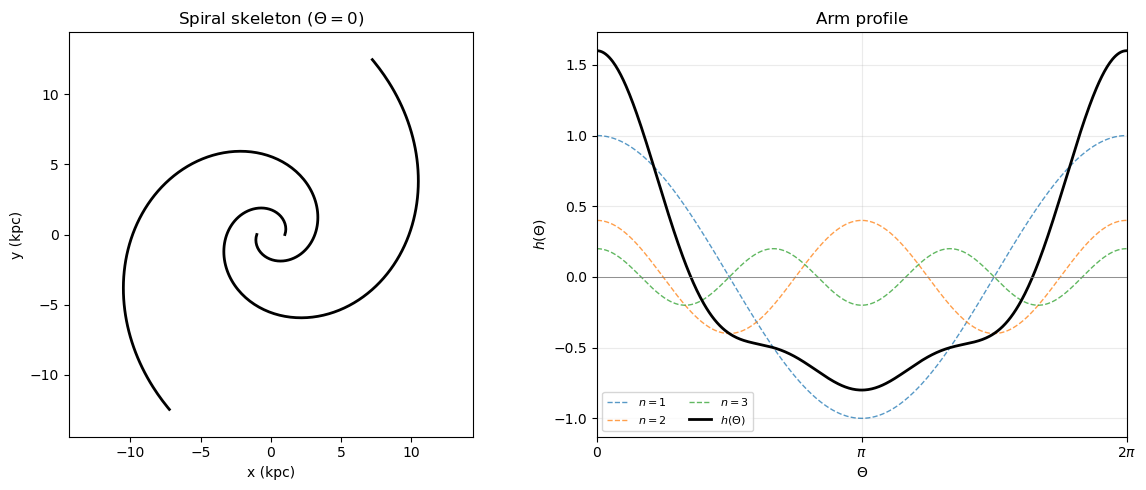

In [2]:
# %% Section 2: Definition of auxiliary functions (spiral phase, source rate, wavenumber)
def spiral_phase(varpi, phi):
    r"""Calculate the phase of a logarithmic spiral $\Theta$."""
    Phi = (m_arms / np.tan(pitch_rad)) * np.log(varpi / R_in)
    return Phi - m_arms * phi + Theta0

def lambda_rate(varpi, phi):
    r"""Calculate the non-uniform event rate $\lambda(\varpi,\phi)$."""
    lam0 = lambda0_0 * np.exp(-varpi / h_R)
    Theta = spiral_phase(varpi, phi)
    return lam0 * (1.0 + eta * h_func(Theta))

def k_perp(varpi):
    r"""Compute the local arm-normal wavenumber $k_\perp$."""
    dPhi = (m_arms / np.tan(pitch_rad)) / varpi
    return np.sqrt(dPhi**2 + (m_arms / varpi)**2)

# Visualising the spiral pattern and its arm-profile harmonics.
phi_plot = np.linspace(0, 2*np.pi, 500)
varpi_plot = np.linspace(R_in, R_out, 200)
profile_theta = np.linspace(0, 2*np.pi, 600)
profile_total = h_func(profile_theta)

fig, (ax_spiral, ax_profile) = plt.subplots(1, 2, figsize=(12, 5))
for k in range(m_arms):
    # Solve Phi(varpi) - m*phi + Theta0 = 0 -> phi = (Phi(varpi) + Theta0 + 2*pi*k)/m.
    phi_sp = ((m_arms / np.tan(pitch_rad)) * np.log(varpi_plot / R_in) + Theta0 + 2*np.pi*k) / m_arms
    ax_spiral.plot(varpi_plot * np.cos(phi_sp), varpi_plot * np.sin(phi_sp), 'k-', lw=2)
ax_spiral.set_xlim(-R_out, R_out)
ax_spiral.set_ylim(-R_out, R_out)
ax_spiral.set_aspect('equal')
ax_spiral.set_title(r'Spiral skeleton ($\Theta = 0$)')
ax_spiral.set_xlabel('x (kpc)')
ax_spiral.set_ylabel('y (kpc)')

for n, g, alpha in zip(harmonic_n, harmonic_g, harmonic_alpha):
    component = g*np.cos(n*profile_theta + alpha)
    ax_profile.plot(profile_theta, component, '--', lw=1, alpha=0.75, label=fr'$n={n}$')
ax_profile.plot(profile_theta, profile_total, 'k-', lw=2, label=r'$h(\Theta)$')
ax_profile.axhline(0, color='grey', lw=0.6)
ax_profile.set_xlim(0, 2*np.pi)
ax_profile.set_xticks([0, np.pi, 2*np.pi])
ax_profile.set_xticklabels([r'$0$', r'$\pi$', r'$2\pi$'])
ax_profile.set_xlabel(r'$\Theta$')
ax_profile.set_ylabel(r'$h(\Theta)$')
ax_profile.set_title(r'Arm profile')
ax_profile.grid(alpha=0.25)
ax_profile.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

## Real Data Analysis for NGC4580
Below we load the FITS data and the Brown (2021) catalog to run the deprojection, local-ridge search, profile fitting, and plotting for NGC4580.

## 2. Imports and visible configuration for real data analysis

This cell imports scientific libraries and configures paths and physical constants for the real NGC4580 galaxy. We load the optical center, inclination, and position angle of NGC4580 from Table 1 of Brown et al. (2021). The finite-thickness axis ratio correction $b/a$ (Equation 3 of Huang et al. 2026) is also verified against the upstream logs.

In [3]:
# %% Imports and path configurations for real data analysis
from pathlib import Path
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.coordinates import FK5, SkyCoord
from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u
from scipy.ndimage import gaussian_filter, gaussian_filter1d
from scipy.optimize import least_squares, minimize_scalar

# Setup roots and retrieve target data files
ROOT = Path.cwd().resolve()
FITS_PATH = ROOT / "data/MAUVE/NGC4580_SFR_maps_further.fits"
BROWN_TABLE = ROOT / "data/MAUVE/Brown2021Table1.txt"
SFR_HDU = "LOGSFR_SURFACE_DENSITY"
BIN_HDU = "BIN_ID"

# Adopted parameters from Brown et al. (2021) catalog
DISTANCE_MPC = 16.5
Q0 = 0.2
SURFACE_DENSITY_ALREADY_CORRECTED = True
APPLY_BA_CORRECTION_IN_NOTEBOOK = False
R_REF_KPC = 1.0
M_CANDIDATES = np.arange(1, 7, dtype=int)
# Manual arm-handedness in the deprojected disc plane. True means phi increases
# anticlockwise as radius increases (positive signed pitch); False means clockwise.
SPIRAL_ANTICLOCKWISE = False
SPIRAL_WINDING_SIGN = 1 if SPIRAL_ANTICLOCKWISE else -1
RIDGE_PITCH_GRID_DEG = SPIRAL_WINDING_SIGN * np.arange(5.0, 45.1, 1.0)
RIDGE_PITCH_BOUNDS_DEG = ((5.0, 45.0) if SPIRAL_ANTICLOCKWISE
                          else (-45.0, -5.0))
RIDGE_PITCH_DEFAULT_DEG = 30.0 * SPIRAL_WINDING_SIGN
RIDGE_CORE_WIDTH_KPC = 0.25
RIDGE_WIDTH_SENSITIVITY_KPC = np.array([0.18, 0.22, 0.25, 0.30, 0.35])
RIDGE_BROAD_RATIO = 3.0
RIDGE_N_PHASE = 360
RIDGE_N_SECTORS = 12
RIDGE_MIN_HELD_OUT_SECTORS = 10
RIDGE_SHORTLIST_PER_FAMILY = 5
RIDGE_N_NULL = 8
LOGPOLAR_N_U = 120
LOGPOLAR_N_PHI = 360
LOGPOLAR_N_RADIAL_BANDS = 24
LOGPOLAR_SMOOTH_SIGMA = (0.8, 1.2)
LOGPOLAR_AZIMUTH_BROAD_SIGMA_BINS = 30.0
KTZ_HARMONIC_ORDER = 3
HARMONIC_N = np.arange(1, KTZ_HARMONIC_ORDER + 1, dtype=int)
USE_ALL_VALID_HII_BINS = True
N_BOOTSTRAP = 24
N_BOOTSTRAP_SECTORS = 12
RNG_SEED = 4580
rng = np.random.default_rng(RNG_SEED)


def load_brown_geometry(path, galaxy="NGC 4580"):
    """
    Load central coordinates, inclination, and position angle from table file.
    """
    if not path.exists():
        raise FileNotFoundError(path)
    # Select lines starting with galaxy name
    rows = [line.rstrip("\n") for line in path.read_text(encoding="utf-8").splitlines()
            if line.startswith(galaxy)]
    if len(rows) != 1:
        raise RuntimeError(f"Expected one {galaxy} row in {path}; found {len(rows)}")
    fields = rows[0].split("\t")
    if len(fields) < 6:
        raise ValueError(f"Malformed Brown table row: {rows[0]}")
    ra_match = re.fullmatch(r"(\d+)\^h(\d+)\^m(\d+)\.s(\d+)", fields[1])
    dec_match = re.fullmatch(r"([+-]?\d+)deg(\d+)'(\d+)\.\"(\d+)", fields[2])
    if ra_match is None or dec_match is None:
        raise ValueError(f"Unrecognized Brown coordinates: {fields[1:3]}")
    hh, mm, ss, sf = ra_match.groups()
    dd, dm, ds, df = dec_match.groups()
    sign = "-" if dd.startswith("-") else "+"
    dd_abs = dd.lstrip("+-")
    # Parse coordinates to celestial coordinates
    coordinate = SkyCoord(
        f"{hh}h{mm}m{ss}.{sf}s",
        f"{sign}{dd_abs}d{dm}m{ds}.{df}s",
        frame=FK5(equinox="J2000"),
    )
    return {
        "center": coordinate,
        "inclination_deg": float(fields[4]),
        "position_angle_deg": float(fields[5]),
        "source_row": rows[0],
    }


def finite_thickness_axis_ratio(inclination_deg, q0=Q0):
    """
    Calculate intrinsic axis ratio b/a from inclination (Equation 3 of Huang 2026).
    """
    cosine = np.cos(np.deg2rad(float(inclination_deg)))
    return float(np.sqrt((1.0 - q0**2) * cosine**2 + q0**2))


# Set up the geometry parameters
BROWN_GEOMETRY = load_brown_geometry(BROWN_TABLE)
CENTER = BROWN_GEOMETRY["center"]
INCLINATION_DEG = BROWN_GEOMETRY["inclination_deg"]
POSITION_ANGLE_DEG = BROWN_GEOMETRY["position_angle_deg"]
B_OVER_A = finite_thickness_axis_ratio(INCLINATION_DEG)
assert SURFACE_DENSITY_ALREADY_CORRECTED
assert not APPLY_BA_CORRECTION_IN_NOTEBOOK
print(f"Brown catalog row: {BROWN_GEOMETRY['source_row']}")
print(f"Adopted FK5 J2000 centre: {CENTER.to_string('hmsdms')}")
print(f"Inclination={INCLINATION_DEG:.1f} deg; directed PA={POSITION_ANGLE_DEG:.1f} deg east of north")
print("BROWN_GEOMETRY_PASS")
print(f"Equation-3 finite-thickness factor b/a={B_OVER_A:.4f}; derived from catalog inclination with q0={Q0}")
print("BA_FACTOR_PASS")

plt.style.use("default")
plt.rcParams.update({"figure.dpi": 115, "font.size": 10})
warnings.filterwarnings("default")
print(f"Spiral winding: {'anticlockwise' if SPIRAL_ANTICLOCKWISE else 'clockwise'} "
      f"outward in the deprojected disc (pitch sign {SPIRAL_WINDING_SIGN:+d})")
print(f"Project root: {ROOT}")
print(f"SFR-map and adaptive-bin input: {FITS_PATH}")

Brown catalog row: NGC 4580 ^a	12^h37^m48.s38	05deg22'06."24	1227	46	337	
Adopted FK5 J2000 centre: 12h37m48.38s +05d22m06.24s
Inclination=46.0 deg; directed PA=337.0 deg east of north
BROWN_GEOMETRY_PASS
Equation-3 finite-thickness factor b/a=0.7094; derived from catalog inclination with q0=0.2
BA_FACTOR_PASS
Spiral winding: clockwise outward in the deprojected disc (pitch sign -1)
Project root: /Users/Igniz/Desktop/ICRAR/KTZ_Theory_z_fluctuation_III
SFR-map and adaptive-bin input: /Users/Igniz/Desktop/ICRAR/KTZ_Theory_z_fluctuation_III/data/MAUVE/NGC4580_SFR_maps_further.fits


## 3. Read the two FITS maps and validate their shared geometry

We load the spatial maps from the FITS file: `LOGSFR_SURFACE_DENSITY_SF` contains the log-SFR surface density and `BIN_ID` contains the adaptive gas-bin pixel mapping. We collapse repeating pixels to build a catalog of independent gas-bin centroids, recording RA/Dec sky coordinates, average SFR, and area weights.

In [4]:
def load_maps(path, sfr_hdu=SFR_HDU, bin_hdu=BIN_HDU):
    """
    Read the log-SFR and bin-ID maps from one product and return WCS parameters.
    """
    if not path.exists():
        raise FileNotFoundError(path)
    with fits.open(path, memmap=True) as hdul:
        names = {hdu.name for hdu in hdul}
        missing = [name for name in (sfr_hdu, bin_hdu) if name not in names]
        if missing:
            raise KeyError(f"Missing required HDUs {missing} in {path}")
        log_sfr = np.asarray(hdul[sfr_hdu].data, dtype=float).copy()
        header = hdul[sfr_hdu].header.copy()
        bin_id = np.asarray(hdul[bin_hdu].data, dtype=float).copy()
    if log_sfr.shape != bin_id.shape:
        raise ValueError(f"Map shape mismatch: {log_sfr.shape} versus {bin_id.shape}")
    wcs = WCS(header).celestial
    if not wcs.has_celestial:
        raise ValueError("Target HDU does not contain a celestial WCS")
    return log_sfr, bin_id, header, wcs


# Perform loading
log_sfr_map, bin_id_map, sfr_header, celestial_wcs = load_maps(FITS_PATH)
wcs_reference = SkyCoord(
    celestial_wcs.wcs.crval[0] * u.deg,
    celestial_wcs.wcs.crval[1] * u.deg,
    frame=FK5(equinox="J2000"),
)
wcs_center_separation_arcsec = float(
    wcs_reference.separation(CENTER).to_value(u.arcsec))
assert wcs_center_separation_arcsec > 1.0
print(f"FITS CRVAL is a WCS projection reference, not the Brown optical centre; "
      f"separation={wcs_center_separation_arcsec:.3f} arcsec")
print("WCS_REFERENCE_NOT_CENTER_PASS")
finite_sfr = np.isfinite(log_sfr_map)
print(f"Map shape: {log_sfr_map.shape}")
print(f"Finite HII SFR pixels: {finite_sfr.sum():,}")
print(f"Finite log SFR range: {np.nanmin(log_sfr_map):.3f} to {np.nanmax(log_sfr_map):.3f}")


def build_bin_catalog(log_sfr, bin_id, wcs):
    """
    Collapse pixels matching each adaptive gas bin to calculate average properties.
    """
    valid = np.isfinite(log_sfr) & np.isfinite(bin_id) & (bin_id >= 0)
    yy, xx = np.nonzero(valid)
    ids = bin_id[valid].astype(np.int64)
    values = log_sfr[valid]
    unique_ids, inverse = np.unique(ids, return_inverse=True)
    # Aggregate pixel coordinates and SFR values per bin ID
    area_pix = np.bincount(inverse).astype(float)
    x_centroid = np.bincount(inverse, weights=xx) / area_pix
    y_centroid = np.bincount(inverse, weights=yy) / area_pix
    mean_log_sfr = np.bincount(inverse, weights=values) / area_pix
    ra_deg, dec_deg = wcs.pixel_to_world_values(x_centroid, y_centroid)
    table = pd.DataFrame({
        "bin_id": unique_ids,
        "x_pix": x_centroid,
        "y_pix": y_centroid,
        "ra_deg": ra_deg,
        "dec_deg": dec_deg,
        "area_pix": area_pix,
        "log_sfr": mean_log_sfr,
        "sfr_linear": np.power(10.0, mean_log_sfr),
    })
    if len(table) < 100:
        raise ValueError(f"Only {len(table)} valid HII bins; spiral fitting is not supported")
    return table, valid


bin_table, valid_hii_pixels = build_bin_catalog(log_sfr_map, bin_id_map, celestial_wcs)
assert bin_table["bin_id"].is_unique
assert np.all(bin_table["area_pix"] > 0)
assert np.all(np.isfinite(bin_table["sfr_linear"]))
print(f"Independent valid HII gas bins: {len(bin_table):,}")
print(f"Median represented area: {bin_table['area_pix'].median():.0f} image pixels")
display(bin_table.head())

FITS CRVAL is a WCS projection reference, not the Brown optical centre; separation=26.474 arcsec
WCS_REFERENCE_NOT_CENTER_PASS
Map shape: (619, 647)
Finite HII SFR pixels: 180,999
Finite log SFR range: -4.046 to -0.545
Independent valid HII gas bins: 7,232
Median represented area: 8 image pixels


,bin_id,x_pix,y_pix,ra_deg,dec_deg,area_pix,log_sfr,sfr_linear
0,0,311.0,314.0,189.451594,5.368508,1.0,-1.363845,0.043267
1,1,312.0,314.0,189.451538,5.368508,1.0,-1.197405,0.063474
2,2,312.0,313.0,189.451538,5.368453,1.0,-1.332339,0.046522
3,3,311.0,313.0,189.451594,5.368453,1.0,-1.399009,0.039902
4,4,313.0,314.0,189.451483,5.368508,1.0,-1.332964,0.046455


## 4. Inspect the observed map and the adopted sky-plane geometry

To verify sky orientation and coordinate systems, we plot the observed log-SFR map on the sky plane. We overlay the adopted optical center and draw the major and minor axis projections based on the position angle. This visual sanity check ensures coordinates are not inverted before tangent-plane rotation.

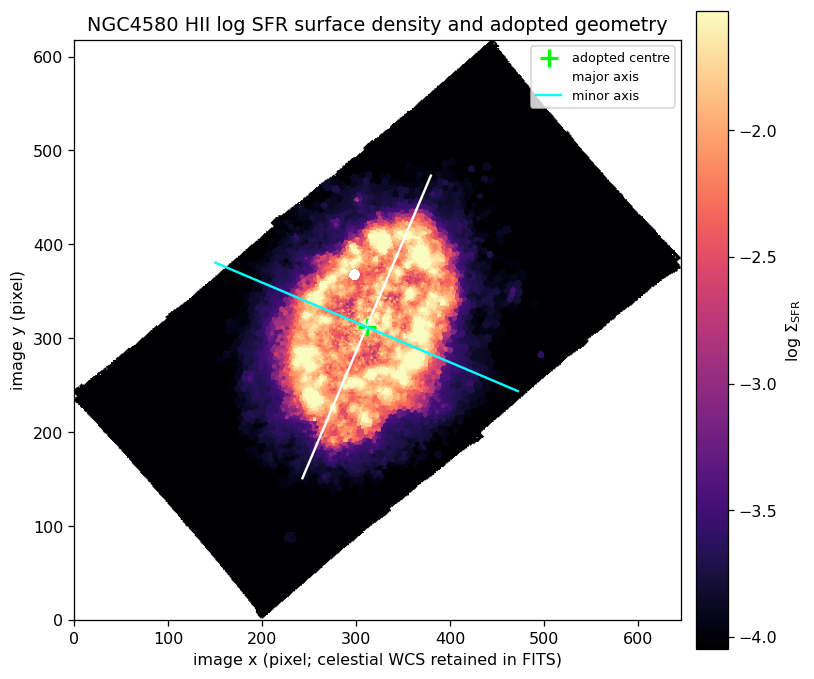

In [5]:
fig, ax = plt.subplots(figsize=(8.2, 7.2))
vmin, vmax = np.nanpercentile(log_sfr_map[finite_sfr], [2, 98])
image = ax.imshow(log_sfr_map, origin="lower", cmap="magma", vmin=vmin, vmax=vmax)
cx, cy = celestial_wcs.world_to_pixel(CENTER)
ax.scatter(cx, cy, marker="+", s=140, linewidth=2.0, color="lime", label="adopted centre")
length_pix = 260.0
pa = np.deg2rad(POSITION_ANGLE_DEG)
# Image x increases approximately east-to-west because CDELT1 is negative; draw axes via sky offsets.
for angle_deg, color, label in [(POSITION_ANGLE_DEG, "white", "major axis"),
                                (POSITION_ANGLE_DEG + 90.0, "cyan", "minor axis")]:
    angle = np.deg2rad(angle_deg)
    dra = np.sin(angle) * 35.0 * u.arcsec
    ddec = np.cos(angle) * 35.0 * u.arcsec
    end1 = CENTER.directional_offset_by(np.arctan2(dra.value, ddec.value) * u.rad,
                                        np.hypot(dra.value, ddec.value) * u.arcsec)
    end2 = CENTER.directional_offset_by((np.arctan2(dra.value, ddec.value) + np.pi) * u.rad,
                                        np.hypot(dra.value, ddec.value) * u.arcsec)
    x1, y1 = celestial_wcs.world_to_pixel(end1)
    x2, y2 = celestial_wcs.world_to_pixel(end2)
    ax.plot([x1, x2], [y1, y2], color=color, lw=1.5, label=label)
ax.set_xlim(0, log_sfr_map.shape[1]-1)
ax.set_ylim(0, log_sfr_map.shape[0]-1)
ax.set_aspect("equal")
ax.set_xlabel("image x (pixel; celestial WCS retained in FITS)")
ax.set_ylabel("image y (pixel)")
ax.set_title("NGC4580 HII log SFR surface density and adopted geometry")
ax.legend(loc="upper right", fontsize=8)
fig.colorbar(image, ax=ax, pad=0.02, label=r"log $\Sigma_{\rm SFR}$")
plt.show()

## 5. Deproject gas-bin centroids into the galaxy plane

We rotate the RA/Dec sky coordinates of unique gas bins and individual pixels into the inclined disc coordinates (major/minor axes in kpc). RA/Dec offsets are converted using the distance conversion factor. Inclination correction is applied as a projection scale on the minor axis (`minor = projected_minor / cos(i)`). This face-on reconstruction defines the radius $R$ and azimuthal angle $\phi$ for every spaxel.

1 arcsec = 0.0800 kpc at 16.5 Mpc
Fitting radius: 0.0041 to 6.3844 kpc; no artificial centre or outer cut
Retained bins: 7,232 / 7,232
Represented valid HII pixels: 180,999 / 180,999
FIT_DOMAIN_ALL_VALID_HII_PASS
Ridge morphology pixels: 180,999 / 180,999
Ridge pixel radius: 0.0041 to 7.1761 kpc; phase pivot=3.275 kpc
RIDGE_PIXEL_DOMAIN_PASS


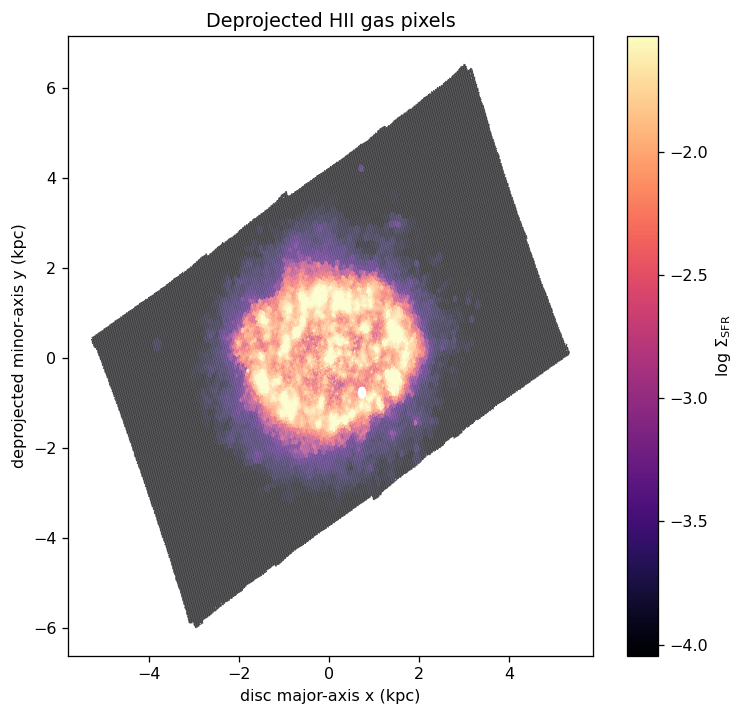

In [6]:
# Convert angular offsets on sky to physical distances in kpc
ARCSEC_TO_KPC = DISTANCE_MPC * 1.0e3 / 206265.0


def deproject_sky(ra_deg, dec_deg):
    """
    Convert sky plane coordinates (RA/Dec) to face-on coordinates in kpc.
    """
    coords = SkyCoord(np.asarray(ra_deg) * u.deg,
                      np.asarray(dec_deg) * u.deg,
                      frame=FK5(equinox="J2000"))
    dlon, dlat = CENTER.spherical_offsets_to(coords)
    east_kpc = dlon.to_value(u.arcsec) * ARCSEC_TO_KPC
    north_kpc = dlat.to_value(u.arcsec) * ARCSEC_TO_KPC
    pa_rad = np.deg2rad(POSITION_ANGLE_DEG)
    inc_rad = np.deg2rad(INCLINATION_DEG)
    # Rotate into PA aligned major/minor coordinates
    major = east_kpc * np.sin(pa_rad) + north_kpc * np.cos(pa_rad)
    minor_projected = -east_kpc * np.cos(pa_rad) + north_kpc * np.sin(pa_rad)
    # Correct minor axis coordinate for inclination
    minor = minor_projected / np.cos(inc_rad)
    radius = np.hypot(major, minor)
    azimuth = np.arctan2(minor, major)
    return major, minor, radius, azimuth


# Direct unit check
origin = deproject_sky([CENTER.ra.deg], [CENTER.dec.deg])
assert np.allclose([origin[0][0], origin[1][0]], 0.0, atol=1.0e-10)

values = deproject_sky(bin_table["ra_deg"], bin_table["dec_deg"])
bin_table[["x_disc_kpc", "y_disc_kpc", "radius_kpc", "azimuth_rad"]] = np.column_stack(values)
fit_mask = np.isfinite(bin_table["radius_kpc"]) & (bin_table["radius_kpc"] > 0.0)
fit_table = bin_table.loc[fit_mask].reset_index(drop=True)
R_IN_KPC = float(fit_table["radius_kpc"].min())
R_OUT_KPC = float(fit_table["radius_kpc"].max())
assert USE_ALL_VALID_HII_BINS
assert len(fit_table) == len(bin_table)
assert int(fit_table["area_pix"].sum()) == int(valid_hii_pixels.sum())
print(f"1 arcsec = {ARCSEC_TO_KPC:.4f} kpc at {DISTANCE_MPC:.1f} Mpc")
print(f"Fitting radius: {R_IN_KPC:.4f} to {R_OUT_KPC:.4f} kpc; no artificial centre or outer cut")
print(f"Retained bins: {len(fit_table):,} / {len(bin_table):,}")
print(f"Represented valid HII pixels: {int(fit_table['area_pix'].sum()):,} / {int(valid_hii_pixels.sum()):,}")
print("FIT_DOMAIN_ALL_VALID_HII_PASS")


def build_hii_pixel_geometry(log_sfr, valid_mask, wcs):
    """
    Create deprojected positions for all pixels to assist morphology ridge searches.
    """
    yy, xx = np.nonzero(valid_mask)
    ra_deg, dec_deg = wcs.pixel_to_world_values(xx, yy)
    major, minor, radius, azimuth = deproject_sky(ra_deg, dec_deg)
    table = pd.DataFrame({
        "x_pix": xx.astype(float),
        "y_pix": yy.astype(float),
        "x_disc_kpc": major,
        "y_disc_kpc": minor,
        "radius_kpc": radius,
        "azimuth_rad": azimuth,
        "log_sfr": log_sfr[valid_mask],
    })
    keep = np.isfinite(table).all(axis=1) & (table["radius_kpc"] > 0)
    result = table.loc[keep].reset_index(drop=True)
    if len(result) != int(valid_mask.sum()):
        raise RuntimeError(f"Lost {int(valid_mask.sum()) - len(result)} valid HII pixels")
    return result


# Build the deprojected pixel mapping table
hii_pixels = build_hii_pixel_geometry(log_sfr_map, valid_hii_pixels, celestial_wcs)
assert len(hii_pixels) == int(valid_hii_pixels.sum())
RIDGE_R_IN_KPC = float(hii_pixels["radius_kpc"].min())
RIDGE_R_OUT_KPC = float(hii_pixels["radius_kpc"].max())
RIDGE_PIVOT_RADIUS_KPC = float(np.exp(
    np.median(np.log(hii_pixels["radius_kpc"].to_numpy(float)))))
print(f"Ridge morphology pixels: {len(hii_pixels):,} / {int(valid_hii_pixels.sum()):,}")
print(f"Ridge pixel radius: {RIDGE_R_IN_KPC:.4f} to {RIDGE_R_OUT_KPC:.4f} kpc; "
      f"phase pivot={RIDGE_PIVOT_RADIUS_KPC:.3f} kpc")
print("RIDGE_PIXEL_DOMAIN_PASS")

fig, ax = plt.subplots(figsize=(7.5, 7.0))
sc = ax.scatter(hii_pixels["x_disc_kpc"], hii_pixels["y_disc_kpc"],
                c=hii_pixels["log_sfr"], s=0.35,
                cmap="magma", vmin=vmin, vmax=vmax, linewidth=0, rasterized=True)
ax.set_aspect("equal")
ax.set_xlabel("disc major-axis x (kpc)")
ax.set_ylabel("deprojected minor-axis y (kpc)")
ax.set_title("Deprojected HII gas pixels")
fig.colorbar(sc, ax=ax, label=r"log $\Sigma_{\rm SFR}$")
plt.show()

## 6. Fit the axisymmetric background and build the log-polar ridge field

We perform a robust exponential fit to the radial SFR profile to find the background normalization $\lambda_0$ and e-folding scale length $h_R$. Subtracting this background yields log-polar residuals. To prevent artificial central holes and normalize localized support, the log-polar map is built using equal-count quantile radial rows.

Axisymmetric SFR background h_R=1.650 kpc; gradient=-0.2632 dex/kpc


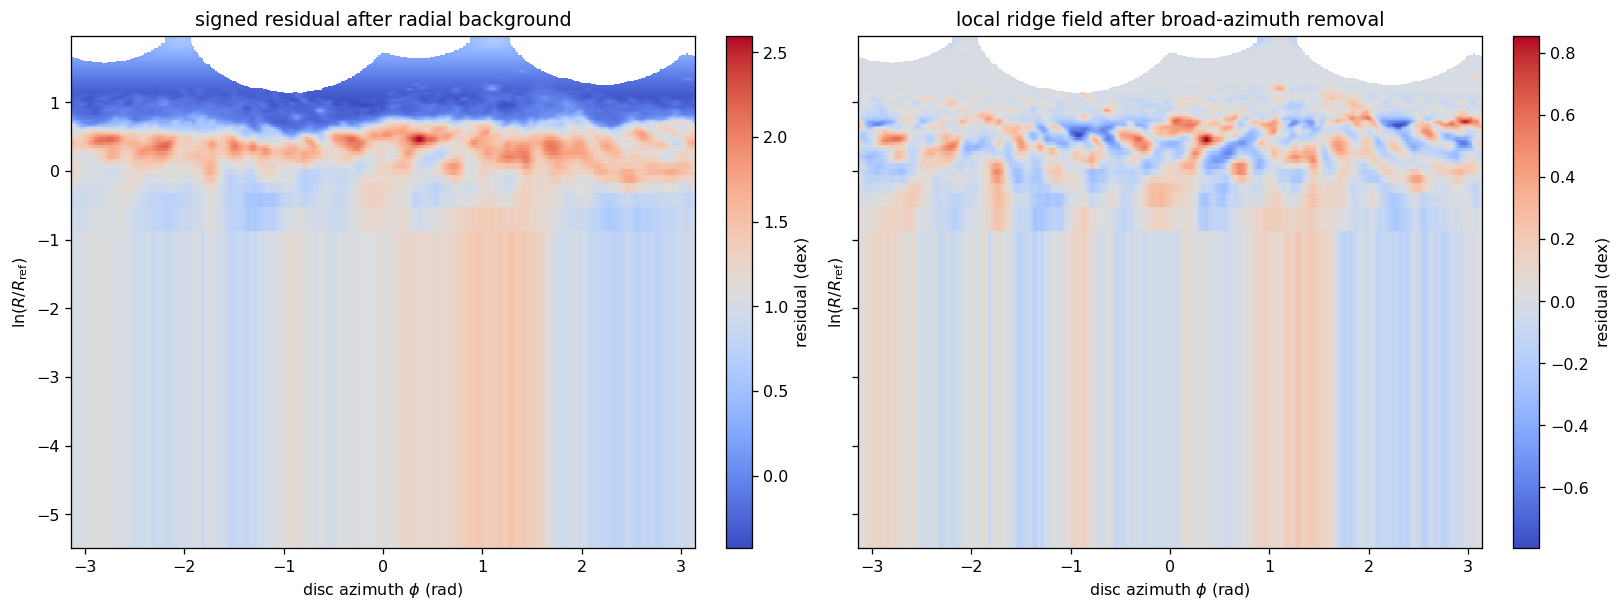

{'lambda0_0': 0.0012282907432310357, 'h_R': 1.65017335499293, 'cost': 74165.99035761553, 'success': True, 'gradient_dex_per_kpc': -0.2631811261460542}


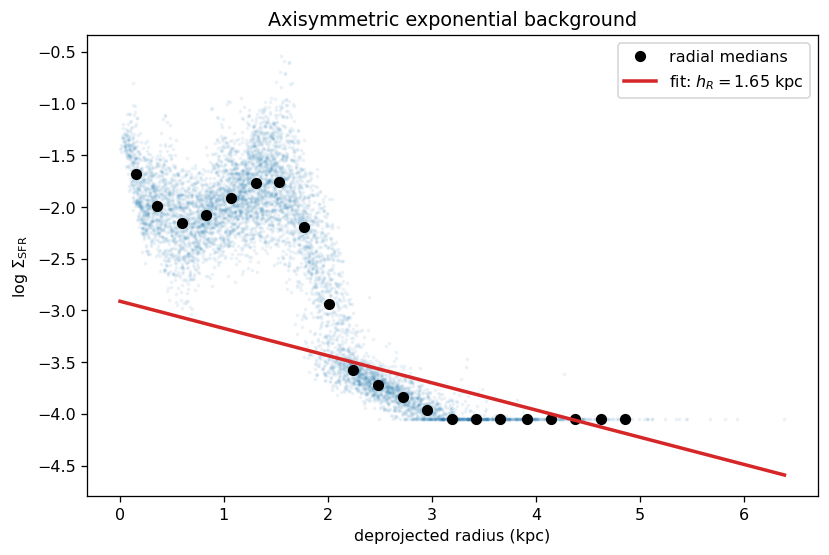

In [7]:
def fit_radial_exponential(radius, sfr_linear, area_weight):
    """Robustly fit lambda0*exp(-R/h_R) in log space using a soft L1 loss."""
    radius = np.asarray(radius, dtype=float)
    sfr_linear = np.asarray(sfr_linear, dtype=float)
    weights = np.sqrt(np.asarray(area_weight, dtype=float))
    valid = (np.isfinite(radius) & np.isfinite(sfr_linear) &
             np.isfinite(weights) & (sfr_linear > 0) & (weights > 0))
    r = radius[valid]
    y = np.log(sfr_linear[valid])
    w = weights[valid] / np.nanmedian(weights[valid])
    initial = np.array([np.nanmedian(y), np.log(3.0)])

    def residual(theta):
        log_lambda0, log_h = theta
        return w * (y - (log_lambda0 - r / np.exp(log_h)))

    result = least_squares(residual, initial, loss="soft_l1", f_scale=0.3,
                           bounds=([-50.0, np.log(0.2)], [50.0, np.log(30.0)]))
    if not result.success:
        raise RuntimeError(result.message)
    return {"lambda0_0": float(np.exp(result.x[0])),
            "h_R": float(np.exp(result.x[1])),
            "cost": float(2.0 * result.cost), "success": True}


# Synthetic unit check
r_test = np.linspace(0.5, 8.0, 200)
radial_test = fit_radial_exponential(r_test, 0.025*np.exp(-r_test/3.4), np.ones_like(r_test))
assert abs(radial_test["h_R"] - 3.4) < 0.02

radial_fit = fit_radial_exponential(hii_pixels["radius_kpc"],
                                    10 ** hii_pixels["log_sfr"],
                                    np.ones_like(hii_pixels["radius_kpc"]))
radial_fit["gradient_dex_per_kpc"] = float(
    -1.0 / (np.log(10.0) * radial_fit["h_R"]))
print(f"Axisymmetric SFR background h_R={radial_fit['h_R']:.3f} kpc; "
      f"gradient={radial_fit['gradient_dex_per_kpc']:.4f} dex/kpc")


def build_log_polar_contrast(
        pixel_table, radial_parameters,
        n_u=LOGPOLAR_N_U, n_phi=LOGPOLAR_N_PHI,
        smooth_sigma=LOGPOLAR_SMOOTH_SIGMA,
        broad_sigma_phi=LOGPOLAR_AZIMUTH_BROAD_SIGMA_BINS):
    """
    Build log-polar map of contrast local ridge residuals.
    """
    radius = pixel_table["radius_kpc"].to_numpy(float)
    azimuth = pixel_table["azimuth_rad"].to_numpy(float)
    observed_log = pixel_table["log_sfr"].to_numpy(float)
    background_log = np.log10(radial_parameters["lambda0_0"]) \
        - radius / (np.log(10.0) * radial_parameters["h_R"])
    signed_residual = observed_log - background_log
    u = np.log(radius / R_REF_KPC)

    # Group into equal-count radial bins
    u_edges = np.quantile(u, np.linspace(0.0, 1.0, n_u + 1))
    if np.any(np.diff(u_edges) <= 0):
        raise RuntimeError("Quantile log-radius edges are not strictly increasing")
    u_edges[0] = np.nextafter(u_edges[0], -np.inf)
    u_edges[-1] = np.nextafter(u_edges[-1], np.inf)
    phi_edges = np.linspace(-np.pi, np.pi, n_phi + 1)
    # Calculate raw 2D histograms
    weighted_sum, _, _ = np.histogram2d(u, azimuth, bins=(u_edges, phi_edges),
                                        weights=signed_residual)
    coverage, _, _ = np.histogram2d(u, azimuth, bins=(u_edges, phi_edges))
    numerator = gaussian_filter(weighted_sum, smooth_sigma,
                                mode=("nearest", "wrap"))
    denominator = gaussian_filter(coverage, smooth_sigma,
                                  mode=("nearest", "wrap"))
    valid = denominator > 0.05
    radial_residual = np.full_like(numerator, np.nan, dtype=float)
    radial_residual[valid] = numerator[valid] / denominator[valid]

    # Construct local ridge contrast field by removing broad azimuthal offsets
    broad_numerator = gaussian_filter1d(
        np.where(valid, radial_residual * denominator, 0.0),
        broad_sigma_phi, axis=1, mode="wrap")
    broad_denominator = gaussian_filter1d(
        np.where(valid, denominator, 0.0),
        broad_sigma_phi, axis=1, mode="wrap")
    broad_azimuthal = np.divide(
        broad_numerator, broad_denominator,
        out=np.zeros_like(broad_numerator), where=broad_denominator > 0)
    local_ridge = np.full_like(radial_residual, np.nan)
    local_ridge[valid] = radial_residual[valid] - broad_azimuthal[valid]

    row_index = np.clip(np.searchsorted(u_edges, u, side="right") - 1,
                        0, n_u - 1)
    row_count = np.bincount(row_index, minlength=n_u)
    u_centres = np.divide(
        np.bincount(row_index, weights=u, minlength=n_u), row_count,
        out=np.full(n_u, np.nan), where=row_count > 0)
    phi_centres = 0.5 * (phi_edges[:-1] + phi_edges[1:])
    return {
        "radial_residual": radial_residual,
        "local_ridge": local_ridge,
        "coverage": denominator,
        "valid": valid,
        "u": u_centres,
        "phi": phi_centres,
        "u_edges": u_edges,
        "phi_edges": phi_edges,
    }


logpolar = build_log_polar_contrast(hii_pixels, radial_fit)
assert np.isfinite(logpolar["local_ridge"][logpolar["valid"]]).all()
assert len(hii_pixels) == int(valid_hii_pixels.sum())

fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.2), constrained_layout=True,
                         sharex=True, sharey=True)
for ax, field, title in zip(
        axes, ["radial_residual", "local_ridge"],
        ["signed residual after radial background",
         "local ridge field after broad-azimuth removal"]):
    image = ax.pcolormesh(
        logpolar["phi_edges"], logpolar["u_edges"], logpolar[field],
        shading="auto", cmap="coolwarm")
    ax.set(xlabel=r"disc azimuth $\phi$ (rad)",
           ylabel=r"$\ln(R/R_{\rm ref})$", title=title)
    fig.colorbar(image, ax=ax, label="residual (dex)")
plt.show()

radial_model = radial_fit["lambda0_0"] * np.exp(-fit_table["radius_kpc"].to_numpy()/radial_fit["h_R"])
fit_table["radial_model"] = radial_model
fit_table["q"] = fit_table["sfr_linear"].to_numpy()/radial_model - 1.0
print(radial_fit)

radial_edges = np.linspace(R_IN_KPC, R_OUT_KPC, 28)
radial_index = np.digitize(fit_table["radius_kpc"], radial_edges) - 1
summary_rows = []
for idx in range(len(radial_edges)-1):
    use = radial_index == idx
    if use.sum() >= 10:
        summary_rows.append((np.median(fit_table.loc[use, "radius_kpc"]),
                             np.median(fit_table.loc[use, "log_sfr"]), use.sum()))
radial_summary = pd.DataFrame(summary_rows, columns=["radius_kpc", "median_log_sfr", "n"])

fig, ax = plt.subplots(figsize=(8.2, 5.2))
ax.scatter(fit_table["radius_kpc"], fit_table["log_sfr"], s=2, alpha=0.06, color="tab:blue")
ax.plot(radial_summary["radius_kpc"], radial_summary["median_log_sfr"], "o", color="black", label="radial medians")
r_line = np.linspace(R_IN_KPC, R_OUT_KPC, 400)
ax.plot(r_line, np.log10(radial_fit["lambda0_0"]*np.exp(-r_line/radial_fit["h_R"])),
        color="tab:red", lw=2.2, label=fr"fit: $h_R={radial_fit['h_R']:.2f}$ kpc")
ax.set(xlabel="deprojected radius (kpc)", ylabel=r"log $\Sigma_{\rm SFR}$",
       title="Axisymmetric exponential background")
ax.legend()
plt.show()

## 7. Fit the logarithmic-spiral geometry for the manually selected winding

We define the logarithmic-spiral phase relative to a reference radius. The global `SPIRAL_ANTICLOCKWISE` switch fixes the arm handedness before fitting: `True` searches positive signed pitch (azimuth increasing anticlockwise with radius) and `False` searches negative signed pitch. NGC4580 uses `True`. The geometry fit determines `m`, signed pitch, and `Theta0`; the later profile fit freezes those values.


In [8]:
def wrap_angle(angle):
    """Wrap angular values into the standard [-pi, pi] domain."""
    return np.angle(np.exp(1j*np.asarray(angle)))


def spiral_phase(radius, azimuth, m_arms, pitch_angle, theta0=0.0):
    """Calculate logarithmic spiral phase Theta (modulo 2pi)."""
    pitch = np.deg2rad(pitch_angle)
    return ((m_arms/np.tan(pitch))*np.log(np.asarray(radius)/R_REF_KPC)
            - m_arms*np.asarray(azimuth) + theta0)


def arm_profile(theta, harmonic_g, harmonic_alpha):
    """Reconstruct the periodic arm profile from its harmonics."""
    theta = np.asarray(theta, dtype=float)
    value = np.zeros_like(theta)
    for n, g, alpha in zip(HARMONIC_N, harmonic_g, harmonic_alpha):
        value += g*np.cos(n*theta + alpha)
    return value


from astropy.modeling import Fittable2DModel, Parameter
from astropy.modeling.fitting import LevMarLSQFitter

class SpiralGeometryCosine2D(Fittable2DModel):
    """Astropy 2D model representing a logarithmic spiral skeleton."""
    inputs = ('radius', 'azimuth')
    outputs = ('value',)
    
    pitch_angle = Parameter(default=RIDGE_PITCH_DEFAULT_DEG,
                            bounds=RIDGE_PITCH_BOUNDS_DEG)
    Theta0 = Parameter(default=0.0, bounds=(0.0, 2.0*np.pi))
    amplitude = Parameter(default=0.01)
    offset = Parameter(default=0.0)
    
    def __init__(self, m_arms=3, *args, **kwargs):
        self.m = m_arms
        super().__init__(*args, **kwargs)
        
    def evaluate(self, radius, azimuth, pitch_angle, Theta0, amplitude, offset):
        pitch = np.deg2rad(pitch_angle)
        if np.abs(pitch) < 1e-4:
            return np.zeros_like(radius)
        u = np.log(radius / R_REF_KPC)
        val = (self.m / np.tan(pitch)) * u - self.m * azimuth + Theta0
        return amplitude * np.cos(val) + offset


def fit_spiral_geometry(logpolar_map_fallback, m_candidates=M_CANDIDATES,
                        pitch_grid=RIDGE_PITCH_GRID_DEG):
    """
    Search the manually selected spiral winding by scanning signed pitch angles
    and refining with an Astropy model fitter.
    """
    g = globals()
    if "fit_table" in g and "radial_fit" in g:
        fit_table = g["fit_table"]
        radial_fit = g["radial_fit"]
        radius = fit_table["radius_kpc"].to_numpy(float)
        azimuth = fit_table["azimuth_rad"].to_numpy(float)
        sfr_linear = fit_table["sfr_linear"].to_numpy(float)
        weights = fit_table["area_pix"].to_numpy(float)
        radial_model = radial_fit["lambda0_0"] * np.exp(-radius / radial_fit["h_R"])
        sfr_resid = sfr_linear - radial_model
        u = np.log(radius / R_REF_KPC)
    else:
        u_grid = logpolar_map_fallback["u"]
        phi_grid = logpolar_map_fallback["phi"]
        radial_residual = logpolar_map_fallback["radial_residual"]
        coverage = logpolar_map_fallback["coverage"]
        valid = logpolar_map_fallback["valid"] & np.isfinite(radial_residual)
        uu, pp = np.meshgrid(u_grid, phi_grid, indexing="ij")
        u = uu[valid]
        azimuth = pp[valid]
        sfr_resid = radial_residual[valid]
        weights = coverage[valid]
        radius = R_REF_KPC * np.exp(u)

    def get_chi2_for_pitch(pitch_deg, u, phi, target_y, weights, m):
        pitch_rad = np.deg2rad(pitch_deg)
        if np.abs(pitch_rad) < 1e-4:
            return np.inf
        X = (m / np.tan(pitch_rad)) * u - m * phi
        M = np.column_stack([np.cos(X), np.sin(X), np.ones_like(X)])
        W = np.sqrt(weights)
        M_w = M * W[:, np.newaxis]
        y_w = target_y * W
        try:
            coef, residuals, rank, s = np.linalg.lstsq(M_w, y_w, rcond=None)
            if len(residuals) > 0:
                return residuals[0]
            else:
                pred = M_w @ coef
                return np.sum((y_w - pred)**2)
        except:
            return np.inf

    pitch_grid = np.asarray(pitch_grid, dtype=float)
    if pitch_grid.size == 0:
        raise ValueError("Pitch grid is empty")
    if np.any(np.sign(pitch_grid) != SPIRAL_WINDING_SIGN):
        raise ValueError("Pitch grid conflicts with SPIRAL_ANTICLOCKWISE")
    
    fitter = LevMarLSQFitter()
    records = []
    
    for m in m_candidates:
        # 1. Grid search for pitch angle initial guess
        chi2_vals = [get_chi2_for_pitch(p, u, azimuth, sfr_resid, weights, m) for p in pitch_grid]
        idx_best = np.argmin(chi2_vals)
        pitch_init = pitch_grid[idx_best]
        
        # 2. Linear regression for other parameters' initial guesses
        pitch_rad = np.deg2rad(pitch_init)
        X = (m / np.tan(pitch_rad)) * u - m * azimuth
        M = np.column_stack([np.cos(X), np.sin(X), np.ones_like(X)])
        W = np.sqrt(weights)
        M_w = M * W[:, np.newaxis]
        y_w = sfr_resid * W
        coef, _, _, _ = np.linalg.lstsq(M_w, y_w, rcond=None)
        a, b, C = coef
        amp_init = np.sqrt(a**2 + b**2)
        theta0_init = np.arctan2(-b, a) % (2.0 * np.pi)
        
        # 3. Initialize Astropy model
        model_init = SpiralGeometryCosine2D(
            m_arms=m,
            pitch_angle=pitch_init,
            Theta0=theta0_init,
            amplitude=amp_init,
            offset=C
        )
        
        # 4. Refine using Astropy fitter
        fitted_model = fitter(model_init, radius, azimuth, sfr_resid, weights=np.sqrt(weights))
        
        pred = fitted_model(radius, azimuth)
        chi2_fit = np.sum(weights * (sfr_resid - pred)**2)
        
        records.append({
            "m_arms": m,
            "pitch_angle": fitted_model.pitch_angle.value,
            "winding_sign": int(np.sign(fitted_model.pitch_angle.value)),
            "Theta0": fitted_model.Theta0.value % (2.0 * np.pi),
            "amplitude": fitted_model.amplitude.value,
            "offset": fitted_model.offset.value,
            "chi2": chi2_fit,
            "fit_score": float(-chi2_fit),
            "n_data_points": int(len(radius)),
        })
        
    geometry_fit_table = pd.DataFrame(records)
    best_geometry_fit = geometry_fit_table.loc[
        geometry_fit_table["chi2"].idxmin()]
    return best_geometry_fit.to_dict(), geometry_fit_table

## 8. Fit the KTZ-compatible source profile on frozen spiral geometry

The profile fit keeps the geometry-fit `m`, signed pitch, and `Theta0` fixed. It fits the radial background, modulation strength $\eta$, and harmonic coefficients $g_n$ and $\alpha_n$. The higher-order harmonic terms can shift the maximum of the total profile away from $\Theta=0$: although $g_1=1$ and $\alpha_1=0$, the $n=2$ and $n=3$ terms generally make $h'(0)\ne0$. The radial parameters and positive scale factor $\eta$ change the amplitude but do not cause this phase shift. Profile maxima are therefore locations on the frozen geometry, not independent geometry fits.


In [9]:
# %% Task 4: Fit KTZ profile at fixed geometry and enumerate maxima
def fit_ktz_profile_fixed_geometry(table, geometry, radial_guess):
    """
    Fit the KTZ source profile parameters at a fixed logarithmic spiral geometry
    using SLSQP optimization with a positivity constraint.
    """
    radius = table["radius_kpc"].to_numpy(float)
    azimuth = table["azimuth_rad"].to_numpy(float)
    observed_log = np.log(table["sfr_linear"].to_numpy(float))
    sqrt_weight = np.sqrt(table["area_pix"].to_numpy(float))
    sqrt_weight /= np.nanmedian(sqrt_weight)
    theta = spiral_phase(radius, azimuth, int(geometry["m_arms"]),
                         float(geometry["pitch_angle"]), float(geometry["Theta0"]))
    
    # Dynamically initialize parameter vectors and bounds based on HARMONIC_N
    n_harm = len(HARMONIC_N)
    
    initial_g = [0.3 * (0.5 ** i) for i in range(n_harm - 1)]
    initial_alpha = [0.0] * (n_harm - 1)
    
    initial = np.concatenate([
        [np.log(radial_guess["lambda0_0"]), np.log(radial_guess["h_R"]), np.log(0.2)],
        initial_g,
        initial_alpha
    ])
    
    lower = np.concatenate([
        [-50.0, np.log(0.2), np.log(1e-4)],
        [0.0] * (n_harm - 1),
        [-np.pi] * (n_harm - 1)
    ])
    
    upper = np.concatenate([
        [50.0, np.log(30.0), np.log(2.0)],
        [1.5] * (n_harm - 1),
        [np.pi] * (n_harm - 1)
    ])
    
    dense_theta = np.linspace(0.0, 2.0*np.pi, 8192, endpoint=False)

    def unpack(values):
        lambda0_0 = float(np.exp(values[0]))
        h_R = float(np.exp(values[1]))
        eta = float(np.exp(values[2]))
        
        g = np.ones(n_harm)
        alpha = np.zeros(n_harm)
        
        g[1:] = values[3 : 2 + n_harm]
        alpha[1:] = values[2 + n_harm : ]
        
        return {
            "lambda0_0": lambda0_0,
            "h_R": h_R,
            "eta": eta,
            "harmonic_n": HARMONIC_N.copy(),
            "harmonic_g": g,
            "harmonic_alpha": alpha,
        }

    from scipy.optimize import minimize, NonlinearConstraint

    def objective(values):
        parameters = unpack(values)
        profile = arm_profile(theta, parameters["harmonic_g"],
                              parameters["harmonic_alpha"])
        factor = 1.0 + parameters["eta"] * profile
        model_log = (np.log(parameters["lambda0_0"])
                     - radius / parameters["h_R"]
                     + np.log(np.clip(factor, 1e-10, None)))
        residuals = sqrt_weight * (observed_log - model_log)
        
        f_scale = 0.25
        z = (residuals / f_scale) ** 2
        rho = 2.0 * (np.sqrt(1.0 + z) - 1.0) * (f_scale ** 2)
        return np.sum(rho)

    def constraint_func(values):
        parameters = unpack(values)
        dense_factor = 1.0 + parameters["eta"] * arm_profile(
            dense_theta, parameters["harmonic_g"], parameters["harmonic_alpha"])
        return np.min(dense_factor)

    nl_constraint = NonlinearConstraint(constraint_func, 1e-3, np.inf)
    bounds_list = list(zip(lower, upper))

    result = minimize(objective, initial, method="SLSQP", bounds=bounds_list,
                      constraints=nl_constraint, options={"maxiter": 3000})
    parameters = unpack(result.x)

    profile = arm_profile(theta, parameters["harmonic_g"], parameters["harmonic_alpha"])
    factor = 1.0 + parameters["eta"] * profile
    model_log = (np.log(parameters["lambda0_0"])
                 - radius / parameters["h_R"]
                 + np.log(np.clip(factor, 1e-10, None)))
    final_residuals = sqrt_weight * (observed_log - model_log)

    minimum_factor = float(np.min(1.0 + parameters["eta"] * arm_profile(
        dense_theta, parameters["harmonic_g"], parameters["harmonic_alpha"])))
    parameters.update({
        "m_arms": int(geometry["m_arms"]),
        "pitch_angle": float(geometry["pitch_angle"]),
        "Theta0": float(geometry["Theta0"]),
        "geometry_source": "spiral_geometry_fit_then_frozen",
        "weighted_log_sse": float(np.sum(final_residuals**2)),
        "positivity_penalty_residual": 0.0,
        "robust_cost": float(result.fun),
        "minimum_rate_factor": minimum_factor,
        "success": bool(result.success and minimum_factor > 0.0),
        "message": result.message,
    })
    if not parameters["success"]:
        raise RuntimeError(f"Fixed-geometry KTZ fit failed: {parameters}")
    return parameters

def enumerate_profile_maxima(model, n_grid=65536):
    """
    Identify and refine the peak values along the fitted arm profile modulation
    to isolate local enhanced maxima.
    """
    theta = np.linspace(0.0, 2.0*np.pi, n_grid, endpoint=False)
    profile = arm_profile(theta, model["harmonic_g"], model["harmonic_alpha"])
    maxima = (profile > np.roll(profile, 1)) & (profile >= np.roll(profile, -1))
    indices = np.flatnonzero(maxima)
    if len(indices) == 0:
        raise RuntimeError("No harmonic-profile maximum found")
    grid_step = 2.0 * np.pi / n_grid

    def profile_scalar(value):
        wrapped_value = float(value % (2.0*np.pi))
        return float(arm_profile(
            np.array([wrapped_value]),
            model["harmonic_g"], model["harmonic_alpha"])[0])

    rows = []
    for index in indices:
        centre = float(theta[index])
        refined = minimize_scalar(
            lambda offset: -profile_scalar(centre + offset),
            bounds=(-grid_step, grid_step), method="bounded",
            options={"xatol": 1e-12})
        theta_peak = float((centre + refined.x) % (2.0*np.pi))
        h_peak = profile_scalar(theta_peak)
        factor = float(1.0 + model["eta"] * h_peak)
        rows.append({
            "theta_peak": theta_peak,
            "h_peak": h_peak,
            "rate_factor": factor,
            "enhanced_above_background": bool(factor > 1.0),
        })
    return pd.DataFrame(rows).sort_values("rate_factor", ascending=False).reset_index(drop=True)

## 9. Run the spiral geometry fit and fixed-geometry profile fit

We fit the logarithmic-spiral geometry on the observed NGC4580 map for each arm number $m$, obtaining signed pitch and `Theta0`. We then freeze that geometry and fit the KTZ-compatible harmonic source profile on the independent gas-bin records.


In [10]:
# %% Run search and fit KTZ profile on observed data
# Find optimized logarithmic spiral geometry parameters
best_geometry_fit, geometry_fit_table = fit_spiral_geometry(logpolar)
print("SPIRAL_GEOMETRY_FIT_COMPLETE")
print(best_geometry_fit)

print("\n=== SPIRAL GEOMETRY FITTING RESULTS FOR EACH M ===")
print(geometry_fit_table[["m_arms", "pitch_angle", "Theta0", "amplitude", "offset", "chi2"]].to_string(index=False))
print("==================================================")

# Perform fixed-geometry KTZ modulation profile fit
profile_fit = fit_ktz_profile_fixed_geometry(fit_table, best_geometry_fit, radial_fit)
profile_fit["gradient_dex_per_kpc"] = float(-1.0 / (np.log(10.0) * profile_fit["h_R"]))
theta_fit = spiral_phase(
    fit_table["radius_kpc"].to_numpy(float),
    fit_table["azimuth_rad"].to_numpy(float),
    profile_fit["m_arms"], profile_fit["pitch_angle"], profile_fit["Theta0"],
)
rate_factor = 1.0 + profile_fit["eta"] * arm_profile(
    theta_fit, profile_fit["harmonic_g"], profile_fit["harmonic_alpha"])
model_sfr = (profile_fit["lambda0_0"]
             * np.exp(-fit_table["radius_kpc"].to_numpy(float) / profile_fit["h_R"])
             * rate_factor)
fit_table = fit_table.copy()
fit_table["theta_fit"] = np.mod(theta_fit, 2.0*np.pi)
fit_table["rate_factor"] = rate_factor
fit_table["model_sfr"] = model_sfr
fit_table["residual_dex"] = np.log10(
    fit_table["sfr_linear"].to_numpy(float)
    / np.clip(model_sfr, 1e-30, None))
profile_maxima = enumerate_profile_maxima(profile_fit)
print("FIXED_GEOMETRY_PROFILE_FIT_COMPLETE")
print("HARMONIC_MAXIMA_COMPLETE")
print("POSITIVITY_CHECK_PASS")
print(profile_fit)

SPIRAL_GEOMETRY_FIT_COMPLETE
{'m_arms': 2.0, 'pitch_angle': -34.459836138638984, 'winding_sign': -1.0, 'Theta0': 2.7044099651565783, 'amplitude': 0.002007589375591361, 'offset': 0.00297271804017633, 'chi2': 14.913688055562384, 'fit_score': -14.913688055562384, 'n_data_points': 7232.0}

=== SPIRAL GEOMETRY FITTING RESULTS FOR EACH M ===
 m_arms  pitch_angle   Theta0  amplitude   offset      chi2
      1   -29.367477 1.566764   0.001049 0.002644 15.142834
      2   -34.459836 2.704410   0.002008 0.002973 14.913688
      3   -39.836150 0.728293   0.000362 0.002589 15.215948
      4   -38.558602 3.307055   0.000907 0.002679 15.152599
      5    -7.995725 5.787886   0.000306 0.002592 15.218596
      6   -31.343018 0.880328   0.000635 0.002617 15.191540
FIXED_GEOMETRY_PROFILE_FIT_COMPLETE
HARMONIC_MAXIMA_COMPLETE
POSITIVITY_CHECK_PASS
{'lambda0_0': 0.03049018083051883, 'h_R': 0.6147221672215603, 'eta': 0.00010000000000000009, 'harmonic_n': array([1, 2, 3]), 'harmonic_g': array([1.00000000e+0

/opt/miniconda3/envs/ICRAR/lib/python3.13/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


## 10. Visualize geometry-fit references and fixed-geometry profile maxima

We define `evaluate_geometry_and_profile_for_m` to plot the geometry-fit $\Theta=0$ reference and the strongest harmonic-profile maximum on the same frozen logarithmic-spiral geometry. The two curves have identical arm count, signed pitch, winding, and `Theta0`; only the profile phase target differs.


In [11]:
# %% Plot helpers for sky projection
# Reconstruct the spiral arm skeleton coordinates in the disc plane
def skeleton_xy_for_phase(geometry, radius_grid, theta_target=0.0):
    curves = []
    m_arms = int(geometry["m_arms"])
    pitch = np.deg2rad(float(geometry["pitch_angle"]))
    theta0 = float(geometry["Theta0"])
    for branch in range(m_arms):
        phi = ((m_arms / np.tan(pitch)) * np.log(radius_grid / R_REF_KPC)
               + theta0 - theta_target - 2.0*np.pi*branch) / m_arms
        curves.append((radius_grid * np.cos(phi), radius_grid * np.sin(phi)))
    return curves


# Project disc-plane coordinates (kpc) back to sky-plane image pixel coordinates
def project_disc_to_pixel(x_disc, y_disc):
    pa_rad = np.deg2rad(POSITION_ANGLE_DEG)
    inc_rad = np.deg2rad(INCLINATION_DEG)
    major = np.asarray(x_disc)
    minor_projected = np.asarray(y_disc) * np.cos(inc_rad)
    east_kpc = major * np.sin(pa_rad) - minor_projected * np.cos(pa_rad)
    north_kpc = major * np.cos(pa_rad) + minor_projected * np.sin(pa_rad)
    sky = CENTER.spherical_offsets_by(
        east_kpc / ARCSEC_TO_KPC * u.arcsec,
        north_kpc / ARCSEC_TO_KPC * u.arcsec,
    )
    return celestial_wcs.world_to_pixel(sky)


# Comprehensive evaluation, fitting, and plotting helper for a candidate geometry
def evaluate_geometry_and_profile_for_m(geometry):
    # Local copy of fit_table to avoid cross-talk between different cell runs
    m_table = fit_table.copy()
    
    # Fit the KTZ profile at fixed geometry
    profile_fit = fit_ktz_profile_fixed_geometry(m_table, geometry, radial_fit)
    assert profile_fit["m_arms"] == int(geometry["m_arms"])
    assert np.isclose(profile_fit["pitch_angle"], geometry["pitch_angle"])
    assert np.isclose(profile_fit["Theta0"], geometry["Theta0"])
    profile_fit["gradient_dex_per_kpc"] = float(-1.0 / (np.log(10.0) * profile_fit["h_R"]))
    
    # 1. Compute pixel-level model and residuals for continuous mapping
    pixel_r = hii_pixels["radius_kpc"].to_numpy(float)
    pixel_phi = hii_pixels["azimuth_rad"].to_numpy(float)
    pixel_sfr = 10 ** hii_pixels["log_sfr"].to_numpy(float)
    
    pixel_theta = spiral_phase(
        pixel_r, pixel_phi,
        profile_fit["m_arms"], profile_fit["pitch_angle"], profile_fit["Theta0"]
    )
    pixel_rate_factor = 1.0 + profile_fit["eta"] * arm_profile(
        pixel_theta, profile_fit["harmonic_g"], profile_fit["harmonic_alpha"]
    )
    pixel_background = profile_fit["lambda0_0"] * np.exp(-pixel_r / profile_fit["h_R"])
    pixel_model_sfr = pixel_background * pixel_rate_factor
    pixel_residual_dex = np.log10(pixel_sfr / np.clip(pixel_model_sfr, 1e-30, None))
    
    # 2. Compute bin-level properties for profile folding/summary
    theta_fit = spiral_phase(
        m_table["radius_kpc"].to_numpy(float),
        m_table["azimuth_rad"].to_numpy(float),
        profile_fit["m_arms"], profile_fit["pitch_angle"], profile_fit["Theta0"],
    )
    m_table["theta_fit"] = np.mod(theta_fit, 2.0*np.pi)
    m_table["rate_factor"] = 1.0 + profile_fit["eta"] * arm_profile(
        theta_fit, profile_fit["harmonic_g"], profile_fit["harmonic_alpha"])
    m_table["model_sfr"] = (profile_fit["lambda0_0"]
                            * np.exp(-m_table["radius_kpc"].to_numpy(float) / profile_fit["h_R"])
                            * m_table["rate_factor"])
    m_table["residual_dex"] = np.log10(
        m_table["sfr_linear"].to_numpy(float)
        / np.clip(m_table["model_sfr"], 1e-30, None))
    
    profile_maxima = enumerate_profile_maxima(profile_fit)
    
    # 2x2 Diagnostic Plot Layout
    # Create a 2x2 grid of subplots for sky projection, deprojected face-on, model, and residuals
    fig, axes = plt.subplots(2, 2, figsize=(13.5, 12.0), constrained_layout=True)
    ax_sky, ax_face, ax_model, ax_residual = axes.ravel()
    disc_limit = 1.03 * RIDGE_R_OUT_KPC

    radius_grid = np.geomspace(RIDGE_R_IN_KPC, RIDGE_R_OUT_KPC, 1000)
    geometry_reference_curves = skeleton_xy_for_phase(geometry, radius_grid, theta_target=0.0)
    profile_peak_curve_sets = []
    for row in profile_maxima.itertuples(index=False):
        if row.enhanced_above_background:
            profile_peak_curve_sets.append({
                "theta_peak": row.theta_peak,
                "rate_factor": row.rate_factor,
                "curves": skeleton_xy_for_phase(profile_fit, radius_grid, row.theta_peak),
            })

    strongest_profile_peak_curves = (profile_peak_curve_sets[0]["curves"]
                              if profile_peak_curve_sets else [])
    strongest_profile_peak_theta = (profile_peak_curve_sets[0]["theta_peak"]
                          if profile_peak_curve_sets else np.nan)
    strongest_profile_phase_offset = float(wrap_angle(strongest_profile_peak_theta))
    print("Geometry/profile consistency: m, signed pitch, and Theta0 are frozen; "
          f"strongest harmonic maximum has wrapped delta Theta={strongest_profile_phase_offset:.3f} rad")

    sky_image = ax_sky.imshow(log_sfr_map, origin="lower", cmap="magma", vmin=vmin, vmax=vmax)
    for index, (x_curve, y_curve) in enumerate(geometry_reference_curves):
        xp, yp = project_disc_to_pixel(x_curve, y_curve)
        ax_sky.plot(xp, yp, color="cyan", lw=1.8,
                    label="geometry fit: Theta = 0 reference" if index == 0 else "_nolegend_")
    for index, (x_curve, y_curve) in enumerate(strongest_profile_peak_curves):
        xp, yp = project_disc_to_pixel(x_curve, y_curve)
        ax_sky.plot(xp, yp, color="lime", ls="--", lw=1.3,
                    label="profile fit: strongest harmonic maximum (fixed geometry)" if index == 0 else "_nolegend_")
    ax_sky.set(xlim=(0, log_sfr_map.shape[1]-1),
               ylim=(0, log_sfr_map.shape[0]-1),
               xlabel="image x (pixel)", ylabel="image y (pixel)",
               title=f"observed sky-plane log SFR + geometry-fit reference (m = {geometry['m_arms']})")
    ax_sky.set_aspect("equal")
    ax_sky.legend(fontsize=8)
    fig.colorbar(sky_image, ax=ax_sky, shrink=0.82, label=r"log $\Sigma_{\rm SFR}$")

    # Obs panel: continuous deprojected pixel-level map
    face_scatter = ax_face.scatter(hii_pixels["x_disc_kpc"], hii_pixels["y_disc_kpc"],
                                   c=hii_pixels["log_sfr"], s=0.35, cmap="magma",
                                   vmin=vmin, vmax=vmax, linewidth=0, rasterized=True)
    for x_curve, y_curve in geometry_reference_curves:
        ax_face.plot(x_curve, y_curve, color="cyan", lw=1.8)
    for index, (x_curve, y_curve) in enumerate(strongest_profile_peak_curves):
        ax_face.plot(x_curve, y_curve, color="lime", ls="--", lw=1.3,
                     label="profile fit: strongest harmonic maximum (fixed geometry)" if index == 0 else "_nolegend_")
    ax_face.set(xlabel="disc major-axis x (kpc)", ylabel="disc minor-axis y (kpc)",
                title="observed deprojected log SFR + geometry-fit reference",
                xlim=(-disc_limit, disc_limit), ylim=(-disc_limit, disc_limit))
    ax_face.set_aspect("equal")
    ax_face.legend(fontsize=8)
    fig.colorbar(face_scatter, ax=ax_face, shrink=0.82, label=r"log $\Sigma_{\rm SFR}$")

    # Model panel: continuous deprojected pixel-level model map
    model_scatter = ax_model.scatter(hii_pixels["x_disc_kpc"], hii_pixels["y_disc_kpc"],
                                     c=np.log10(pixel_model_sfr), s=0.35, cmap="magma",
                                     vmin=vmin, vmax=vmax, linewidth=0, rasterized=True)
    for peak_index, peak in enumerate(profile_peak_curve_sets):
        width = 0.8 + 1.5 * (peak["rate_factor"] - 1.0)
        colour = f"C{peak_index % 10}"
        for branch_index, (x_curve, y_curve) in enumerate(peak["curves"]):
            label = (fr"model maximum {peak_index+1}: factor={peak['rate_factor']:.2f}"
                     if branch_index == 0 else "_nolegend_")
            ax_model.plot(x_curve, y_curve, color=colour, lw=width, label=label)
    ax_model.set(xlabel="disc major-axis x (kpc)", ylabel="disc minor-axis y (kpc)",
                 title="fitted KTZ-compatible source model + enhanced maxima",
                 xlim=(-disc_limit, disc_limit), ylim=(-disc_limit, disc_limit))
    ax_model.set_aspect("equal")
    ax_model.legend(fontsize=7)
    fig.colorbar(model_scatter, ax=ax_model, shrink=0.82, label=r"model log $\Sigma_{\rm SFR}$")

    # Residual panel: continuous deprojected pixel-level residual map
    limit = np.nanpercentile(np.abs(pixel_residual_dex), 95)
    residual_scatter = ax_residual.scatter(
        hii_pixels["x_disc_kpc"], hii_pixels["y_disc_kpc"],
        c=pixel_residual_dex, s=0.35, cmap="coolwarm",
        vmin=-limit, vmax=limit, linewidth=0, rasterized=True)
    for x_curve, y_curve in geometry_reference_curves:
        ax_residual.plot(x_curve, y_curve, color="cyan", lw=1.8, alpha=0.9)
    ax_residual.set(xlabel="disc major-axis x (kpc)", ylabel="disc minor-axis y (kpc)",
                    title="observed - model residual + geometry-fit reference",
                    xlim=(-disc_limit, disc_limit), ylim=(-disc_limit, disc_limit))
    ax_residual.set_aspect("equal")
    fig.colorbar(residual_scatter, ax=ax_residual, shrink=0.82, label="residual (dex)")
    plt.show()
    print("DEPROJECTED_SFR_SKELETON_PASS")

    # Fitted KTZ-compatible harmonic source profile plot
    # Set up theta grid for plotting the periodic KTZ profile
    theta_grid = np.linspace(0.0, 2.0*np.pi, 1600)
    profile_total = arm_profile(theta_grid, profile_fit["harmonic_g"], profile_fit["harmonic_alpha"])
    rate_factor_grid = 1.0 + profile_fit["eta"] * profile_total

    final_background = (profile_fit["lambda0_0"]
        * np.exp(-m_table["radius_kpc"].to_numpy(float) / profile_fit["h_R"]))
    m_table["q_final_background"] = (
        m_table["sfr_linear"].to_numpy(float) / final_background - 1.0)
    phase_edges = np.linspace(0.0, 2.0*np.pi, 25)
    phase_index = np.digitize(m_table["theta_fit"], phase_edges) - 1
    phase_rows = []
    for phase_bin in range(len(phase_edges) - 1):
        use = phase_index == phase_bin
        if use.sum() >= 10:
            values = m_table.loc[use, "q_final_background"].to_numpy(float)
            median = float(np.median(values))
            robust_sigma = float(1.4826 * np.median(np.abs(values - median)))
            phase_rows.append({
                "theta": 0.5 * (phase_edges[phase_bin] + phase_edges[phase_bin + 1]),
                "q_over_eta": median / profile_fit["eta"],
                "q_over_eta_sem": robust_sigma / np.sqrt(use.sum()) / profile_fit["eta"],
            })
    phase_summary = pd.DataFrame(phase_rows)

    fig, ax = plt.subplots(figsize=(10.5, 5.8), constrained_layout=True)
    for n, g, alpha in zip(
            HARMONIC_N, profile_fit["harmonic_g"], profile_fit["harmonic_alpha"]):
        ax.plot(theta_grid, g * np.cos(n*theta_grid + alpha), "--", lw=1,
                label=fr"component $n={n}$")
    ax.plot(theta_grid, profile_total, "k-", lw=2.2, label=r"total $h(\Theta)$")
    if not phase_summary.empty:
        ax.errorbar(phase_summary["theta"], phase_summary["q_over_eta"],
                    yerr=phase_summary["q_over_eta_sem"], fmt="o", ms=3,
                    color="tab:red", alpha=0.75, label="phase-folded data / eta")
    for peak_index, row in enumerate(profile_maxima.itertuples(index=False)):
        if row.enhanced_above_background:
            colour = f"C{(peak_index + 3) % 10}"
            linestyle = "-"
            width = 1.4
            label = f"enhanced maximum {peak_index + 1}"
        else:
            colour = "0.55"
            linestyle = ":"
            width = 0.9
            label = f"below-background maximum {peak_index + 1}"
        ax.axvline(row.theta_peak, color=colour, ls=linestyle, lw=width,
                   label=label)
        ax.annotate(f"factor={row.rate_factor:.2f}",
                    (row.theta_peak, row.h_peak), xytext=(4, 7),
                    textcoords="offset points", rotation=90, fontsize=7,
                    color=colour)
    ax.axhline(0.0, color="0.5", lw=0.7)
    ax.set(xlim=(0.0, 2.0*np.pi), xlabel=r"$\Theta$", ylabel=r"$h(\Theta)$",
           title=f"Fixed-geometry KTZ harmonic profile (m = {geometry['m_arms']})")
    ax.set_xticks([0.0, np.pi, 2.0*np.pi], [r"$0$", r"$\pi$", r"$2\pi$"])
    ax.legend(fontsize=7, ncol=2)
    plt.show()
    print(f"Minimum fitted rate factor: {np.min(rate_factor_grid):.4f}")
    print("POSITIVITY_CHECK_PASS")

    # Parameter table reporting
    # Construct the parameter estimation summary table
    parameter_rows = [
        ("R_in", R_IN_KPC, "kpc", "all positive-radius valid HII bins; no hole"),
        ("R_out", R_OUT_KPC, "kpc", "all valid HII bins; no quantile cut"),
        ("ridge_R_in", RIDGE_R_IN_KPC, "kpc", "all positive-radius valid HII pixels"),
        ("ridge_R_out", RIDGE_R_OUT_KPC, "kpc", "all valid HII morphology pixels"),
        ("m_arms", profile_fit["m_arms"], "integer base mode", "geometry fit; frozen during profile fit"),
        ("pitch_angle", profile_fit["pitch_angle"], "signed deg", "geometry fit; frozen during profile fit"),
        ("Theta0", profile_fit["Theta0"], "rad modulo 2 pi", "geometry fit; frozen during profile fit"),
        ("ridge_core_width", RIDGE_CORE_WIDTH_KPC, "kpc", "declared fiducial local-ridge scale"),
        ("lambda0_0", profile_fit["lambda0_0"], "SFR surface-density normalization", "fixed-geometry KTZ fit; uncertainty not estimated"),
        ("h_R", profile_fit["h_R"], "kpc", "axisymmetric SFR e-folding length; fixed-geometry KTZ fit"),
        ("radial_gradient", profile_fit["gradient_dex_per_kpc"], "dex/kpc", "equals -1 / (ln(10) h_R)"),
        ("eta", profile_fit["eta"], "dimensionless", "fixed-geometry KTZ fit; uncertainty not estimated"),
        ("harmonic_n", str(profile_fit["harmonic_n"].tolist()), "integer orders", "fixed"),
        ("harmonic_g", np.array2string(profile_fit["harmonic_g"], precision=4), "g1=1 normalization", "fixed-geometry KTZ fit"),
        ("harmonic_alpha", np.array2string(profile_fit["harmonic_alpha"], precision=4), "rad; alpha1=0", "fixed-geometry KTZ fit"),
        ("kappa, x0, t_star, clustering", np.nan, "KTZ mixing parameters", "not fitted from SFR morphology"),
    ]
    parameter_table = pd.DataFrame(
        parameter_rows, columns=["parameter", "estimate", "unit_or_convention", "status"])
    display(parameter_table)
    display(profile_maxima)
    print("FINAL_PARAMETER_TABLE_COMPLETE")
    
    return profile_fit

## Geometry and Fixed-Geometry Profile Results for m = 1

/opt/miniconda3/envs/ICRAR/lib/python3.13/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


Geometry/profile consistency: m, signed pitch, and Theta0 are frozen; strongest harmonic maximum has wrapped delta Theta=0.348 rad


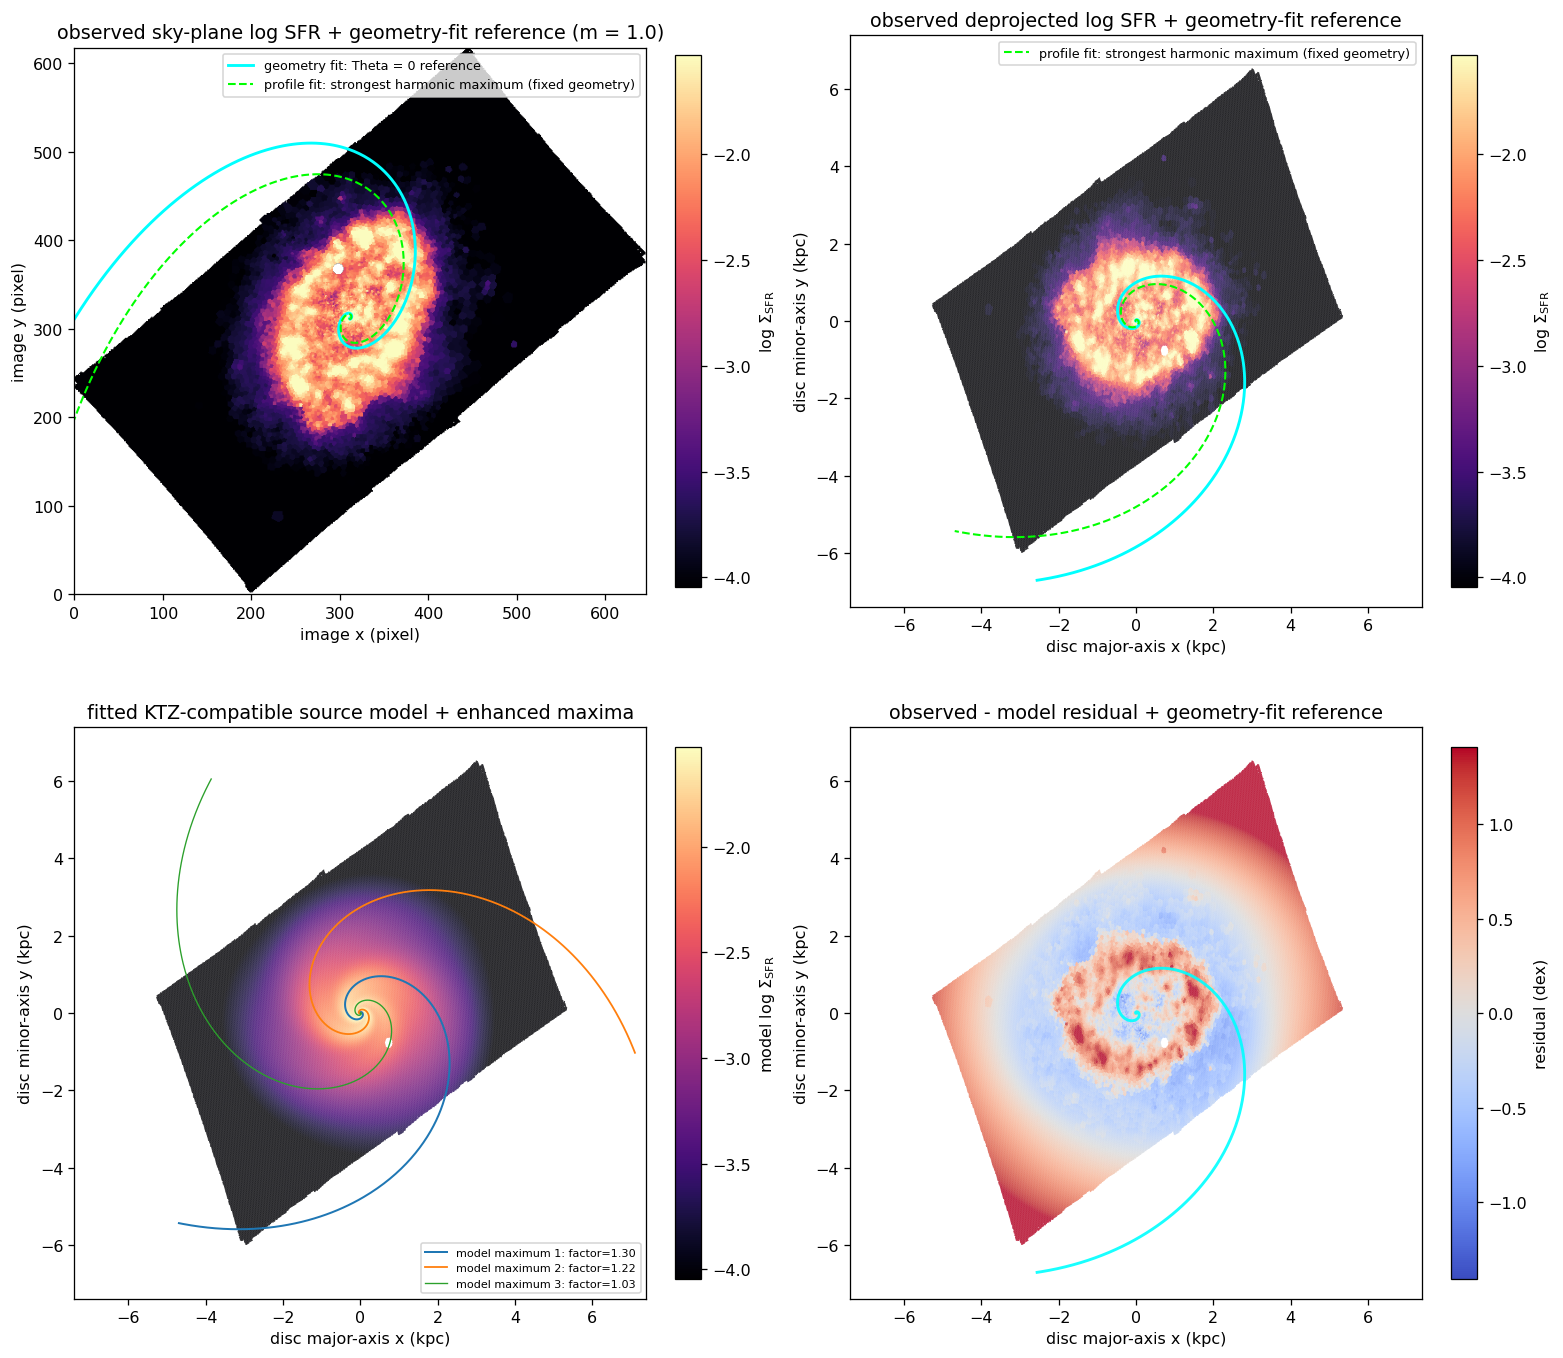

DEPROJECTED_SFR_SKELETON_PASS


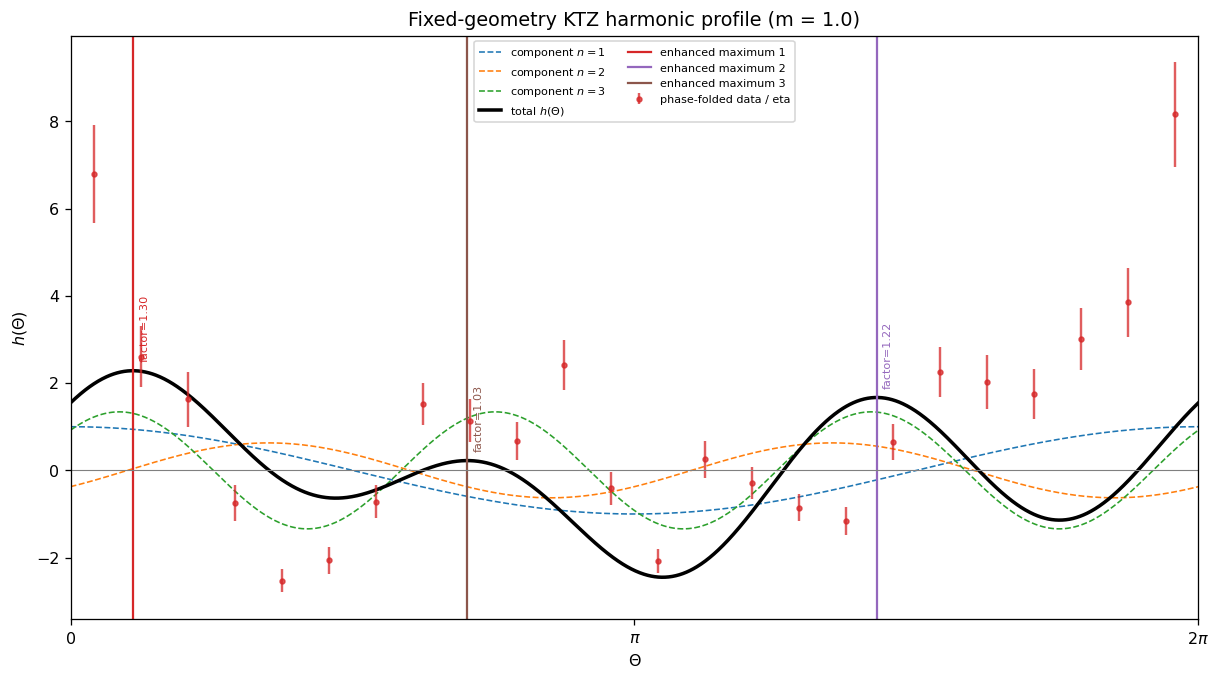

Minimum fitted rate factor: 0.6789
POSITIVITY_CHECK_PASS


,parameter,estimate,unit_or_convention,status
0,R_in,0.004136,kpc,all positive-radius valid HII bins; no hole
1,R_out,6.384442,kpc,all valid HII bins; no quantile cut
2,ridge_R_in,0.004136,kpc,all positive-radius valid HII pixels
3,ridge_R_out,7.176088,kpc,all valid HII morphology pixels
4,m_arms,1,integer base mode,geometry fit; frozen during profile fit
5,pitch_angle,-29.367477,signed deg,geometry fit; frozen during profile fit
6,Theta0,1.566764,rad modulo 2 pi,geometry fit; frozen during profile fit
7,ridge_core_width,0.25,kpc,declared fiducial local-ridge scale
8,lambda0_0,0.030482,SFR surface-density normalization,fixed-geometry KTZ fit; uncertainty not estimated
9,h_R,0.618352,kpc,axisymmetric SFR e-folding length; fixed-geome...


,theta_peak,h_peak,rate_factor,enhanced_above_background
0,0.347607,2.283173,1.299358,True
1,4.491388,1.669514,1.218898,True
2,2.209872,0.223675,1.029327,True


FINAL_PARAMETER_TABLE_COMPLETE


In [12]:
# Retrieve best-fit geometry for m=1 and run evaluation and plotting
geometry_fit_m1 = geometry_fit_table.loc[geometry_fit_table["m_arms"] == 1].iloc[0].to_dict()
profile_fit_m1 = evaluate_geometry_and_profile_for_m(geometry_fit_m1)

## Geometry and Fixed-Geometry Profile Results for m = 2

/opt/miniconda3/envs/ICRAR/lib/python3.13/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


Geometry/profile consistency: m, signed pitch, and Theta0 are frozen; strongest harmonic maximum has wrapped delta Theta=0.866 rad


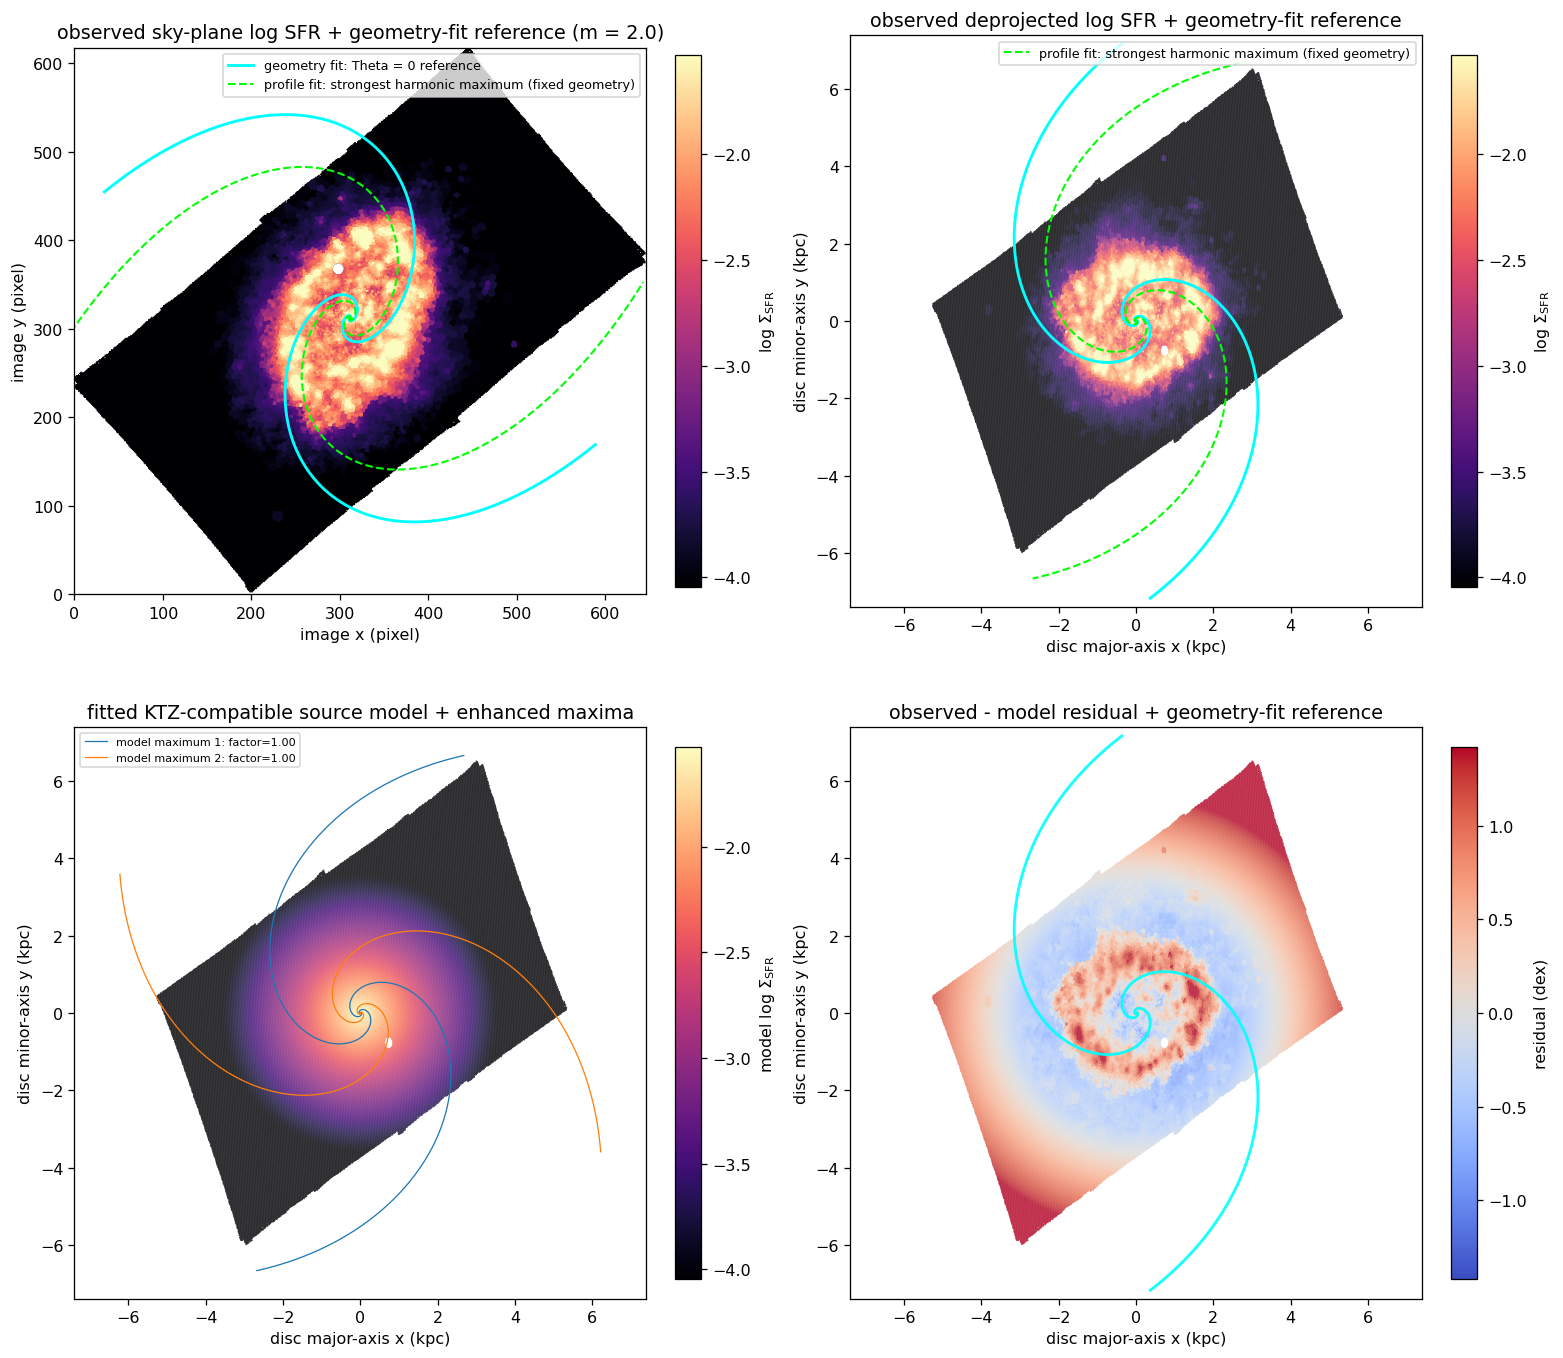

DEPROJECTED_SFR_SKELETON_PASS


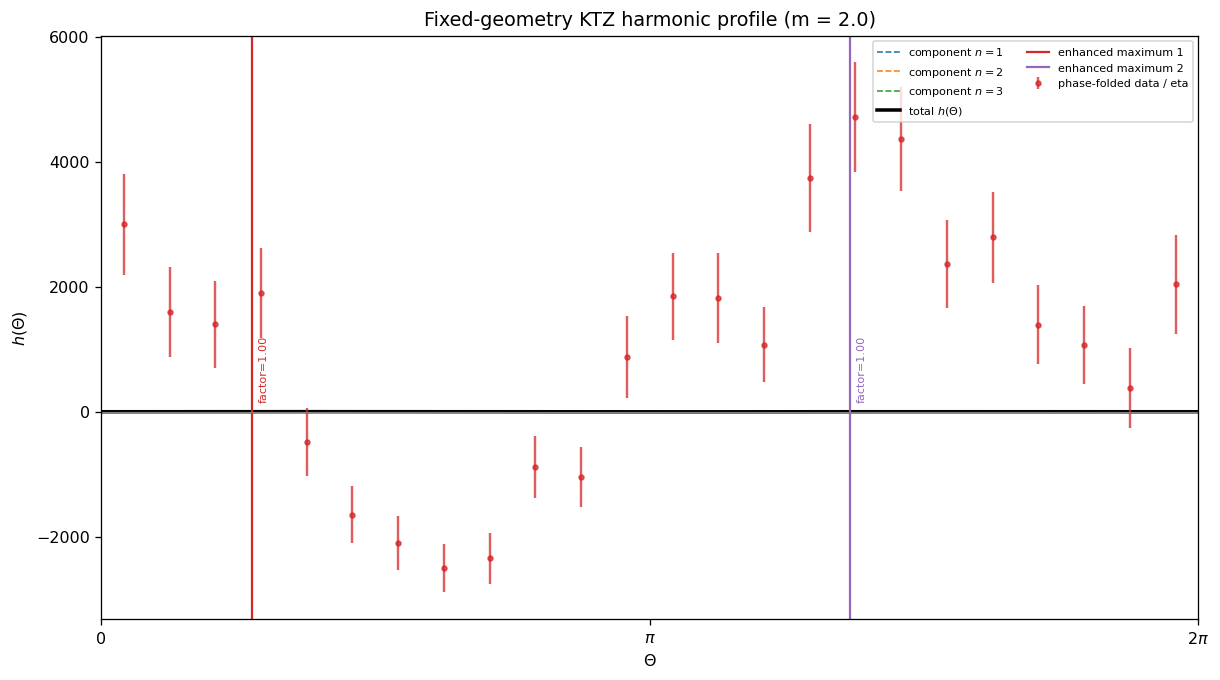

Minimum fitted rate factor: 0.9998
POSITIVITY_CHECK_PASS


,parameter,estimate,unit_or_convention,status
0,R_in,0.004136,kpc,all positive-radius valid HII bins; no hole
1,R_out,6.384442,kpc,all valid HII bins; no quantile cut
2,ridge_R_in,0.004136,kpc,all positive-radius valid HII pixels
3,ridge_R_out,7.176088,kpc,all valid HII morphology pixels
4,m_arms,2,integer base mode,geometry fit; frozen during profile fit
5,pitch_angle,-34.459836,signed deg,geometry fit; frozen during profile fit
6,Theta0,2.70441,rad modulo 2 pi,geometry fit; frozen during profile fit
7,ridge_core_width,0.25,kpc,declared fiducial local-ridge scale
8,lambda0_0,0.03049,SFR surface-density normalization,fixed-geometry KTZ fit; uncertainty not estimated
9,h_R,0.614722,kpc,axisymmetric SFR e-folding length; fixed-geome...


,theta_peak,h_peak,rate_factor,enhanced_above_background
0,0.866125,2.098613,1.000210,True
1,4.290601,1.019559,1.000102,True


FINAL_PARAMETER_TABLE_COMPLETE


In [13]:
# Retrieve best-fit geometry for m=2 and run evaluation and plotting
geometry_fit_m2 = geometry_fit_table.loc[geometry_fit_table["m_arms"] == 2].iloc[0].to_dict()
profile_fit_m2 = evaluate_geometry_and_profile_for_m(geometry_fit_m2)

## Geometry and Fixed-Geometry Profile Results for m = 3

/opt/miniconda3/envs/ICRAR/lib/python3.13/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


Geometry/profile consistency: m, signed pitch, and Theta0 are frozen; strongest harmonic maximum has wrapped delta Theta=1.598 rad


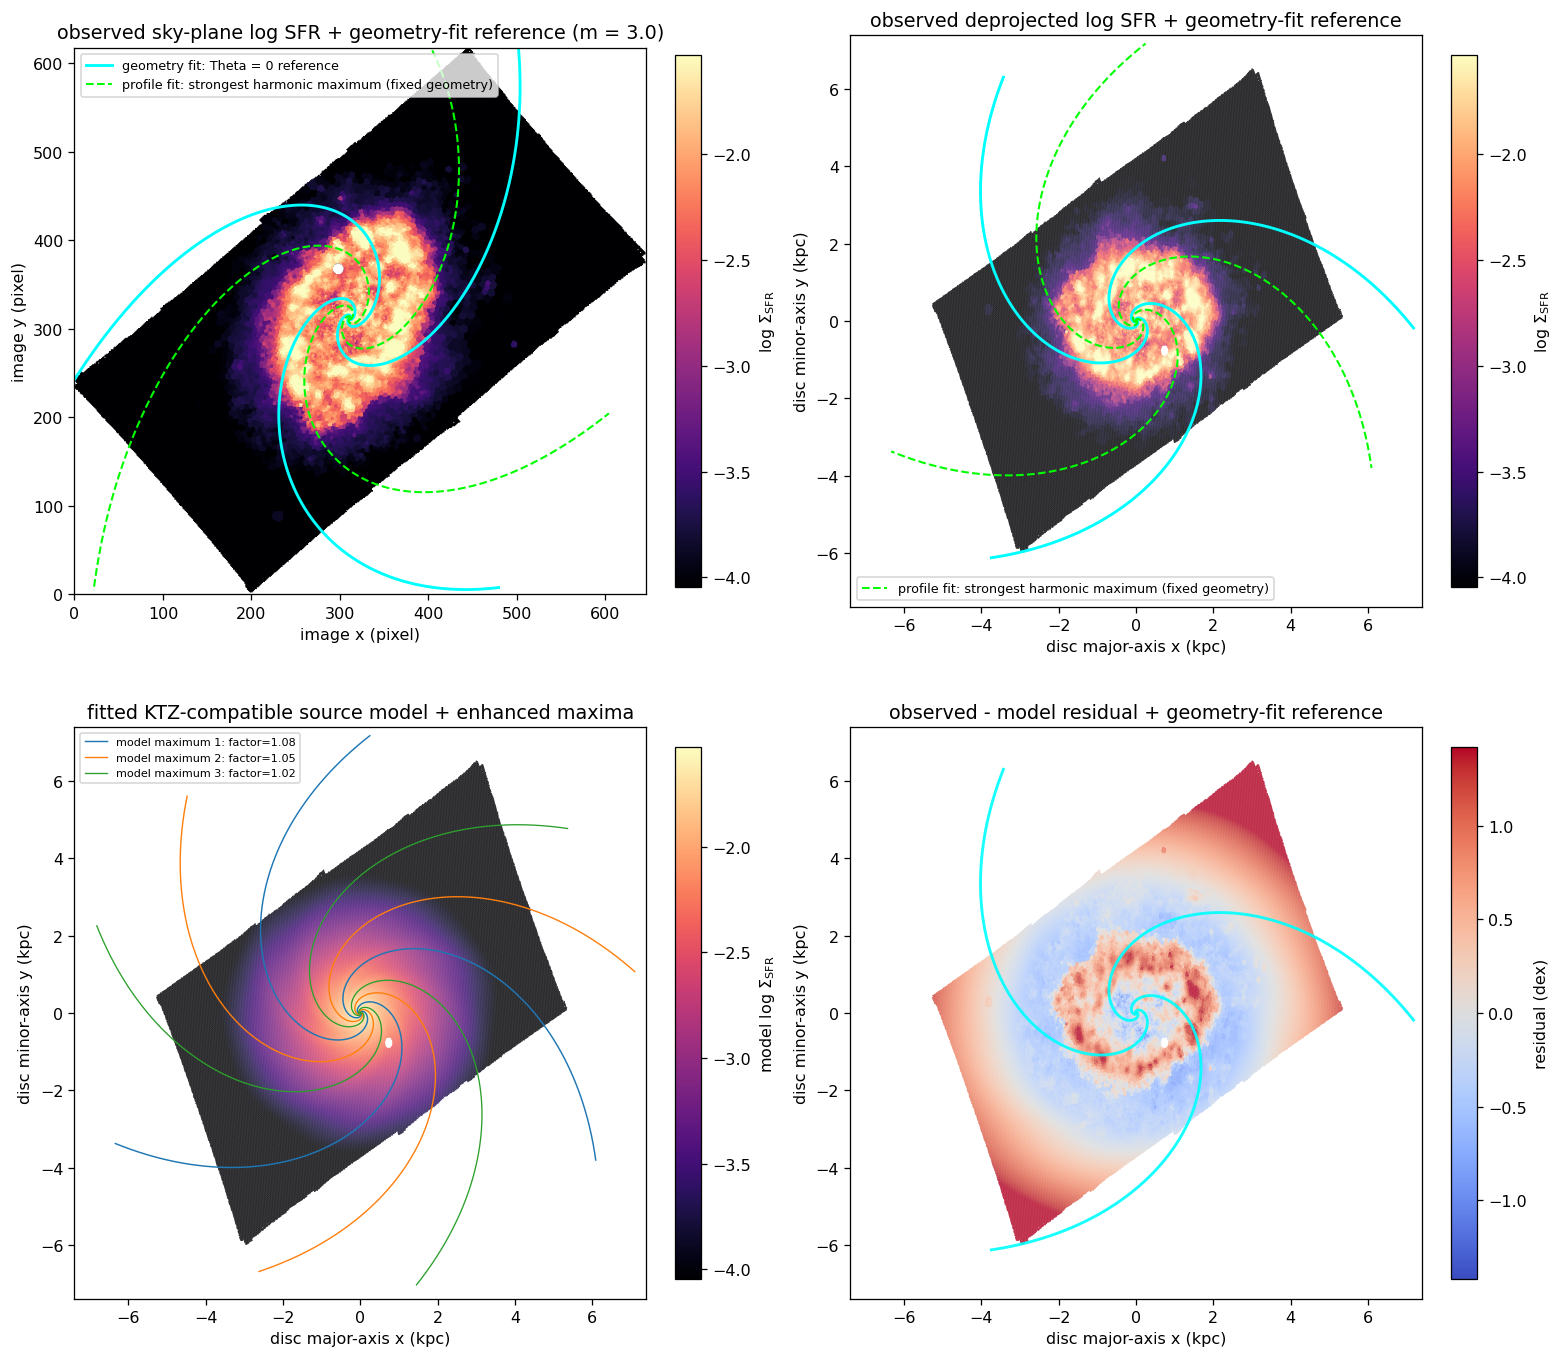

DEPROJECTED_SFR_SKELETON_PASS


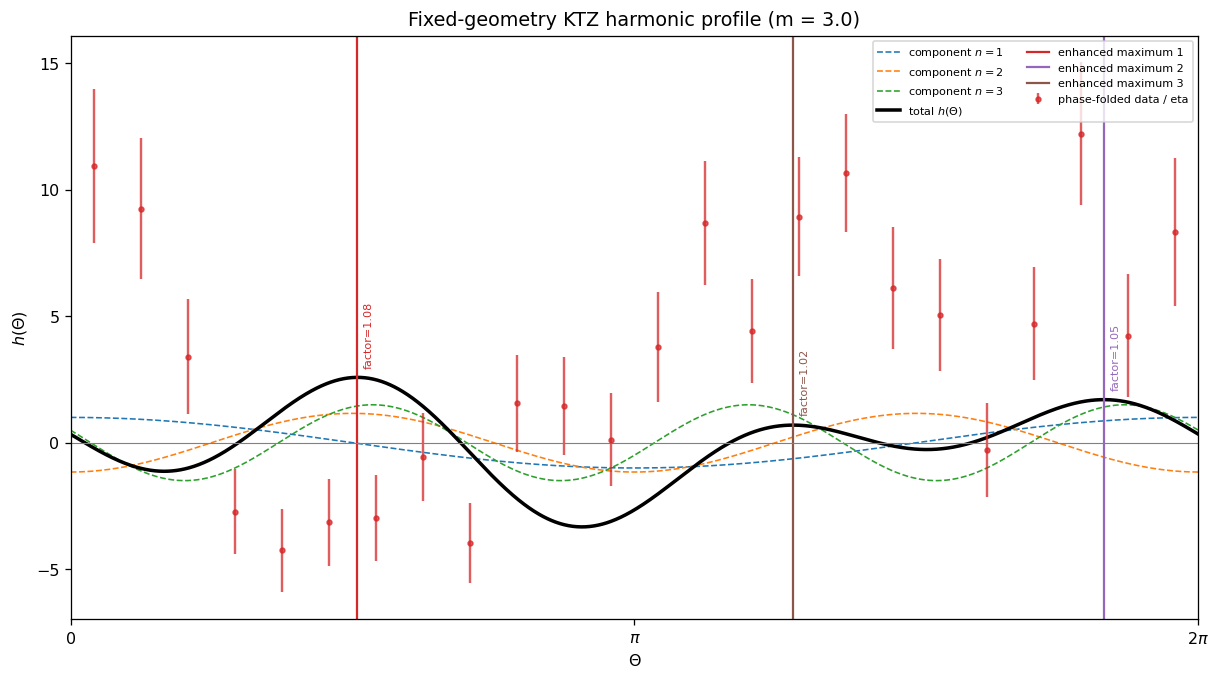

Minimum fitted rate factor: 0.9023
POSITIVITY_CHECK_PASS


,parameter,estimate,unit_or_convention,status
0,R_in,0.004136,kpc,all positive-radius valid HII bins; no hole
1,R_out,6.384442,kpc,all valid HII bins; no quantile cut
2,ridge_R_in,0.004136,kpc,all positive-radius valid HII pixels
3,ridge_R_out,7.176088,kpc,all valid HII morphology pixels
4,m_arms,3,integer base mode,geometry fit; frozen during profile fit
5,pitch_angle,-39.83615,signed deg,geometry fit; frozen during profile fit
6,Theta0,0.728293,rad modulo 2 pi,geometry fit; frozen during profile fit
7,ridge_core_width,0.25,kpc,declared fiducial local-ridge scale
8,lambda0_0,0.030628,SFR surface-density normalization,fixed-geometry KTZ fit; uncertainty not estimated
9,h_R,0.61452,kpc,axisymmetric SFR e-folding length; fixed-geome...


,theta_peak,h_peak,rate_factor,enhanced_above_background
0,1.598286,2.582837,1.075817,True
1,5.757208,1.702416,1.049973,True
2,4.025135,0.695243,1.020408,True


FINAL_PARAMETER_TABLE_COMPLETE


In [14]:
# Retrieve best-fit geometry for m=3 and run evaluation and plotting
geometry_fit_m3 = geometry_fit_table.loc[geometry_fit_table["m_arms"] == 3].iloc[0].to_dict()
profile_fit_m3 = evaluate_geometry_and_profile_for_m(geometry_fit_m3)

## Geometry and Fixed-Geometry Profile Results for m = 4

/opt/miniconda3/envs/ICRAR/lib/python3.13/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


Geometry/profile consistency: m, signed pitch, and Theta0 are frozen; strongest harmonic maximum has wrapped delta Theta=0.245 rad


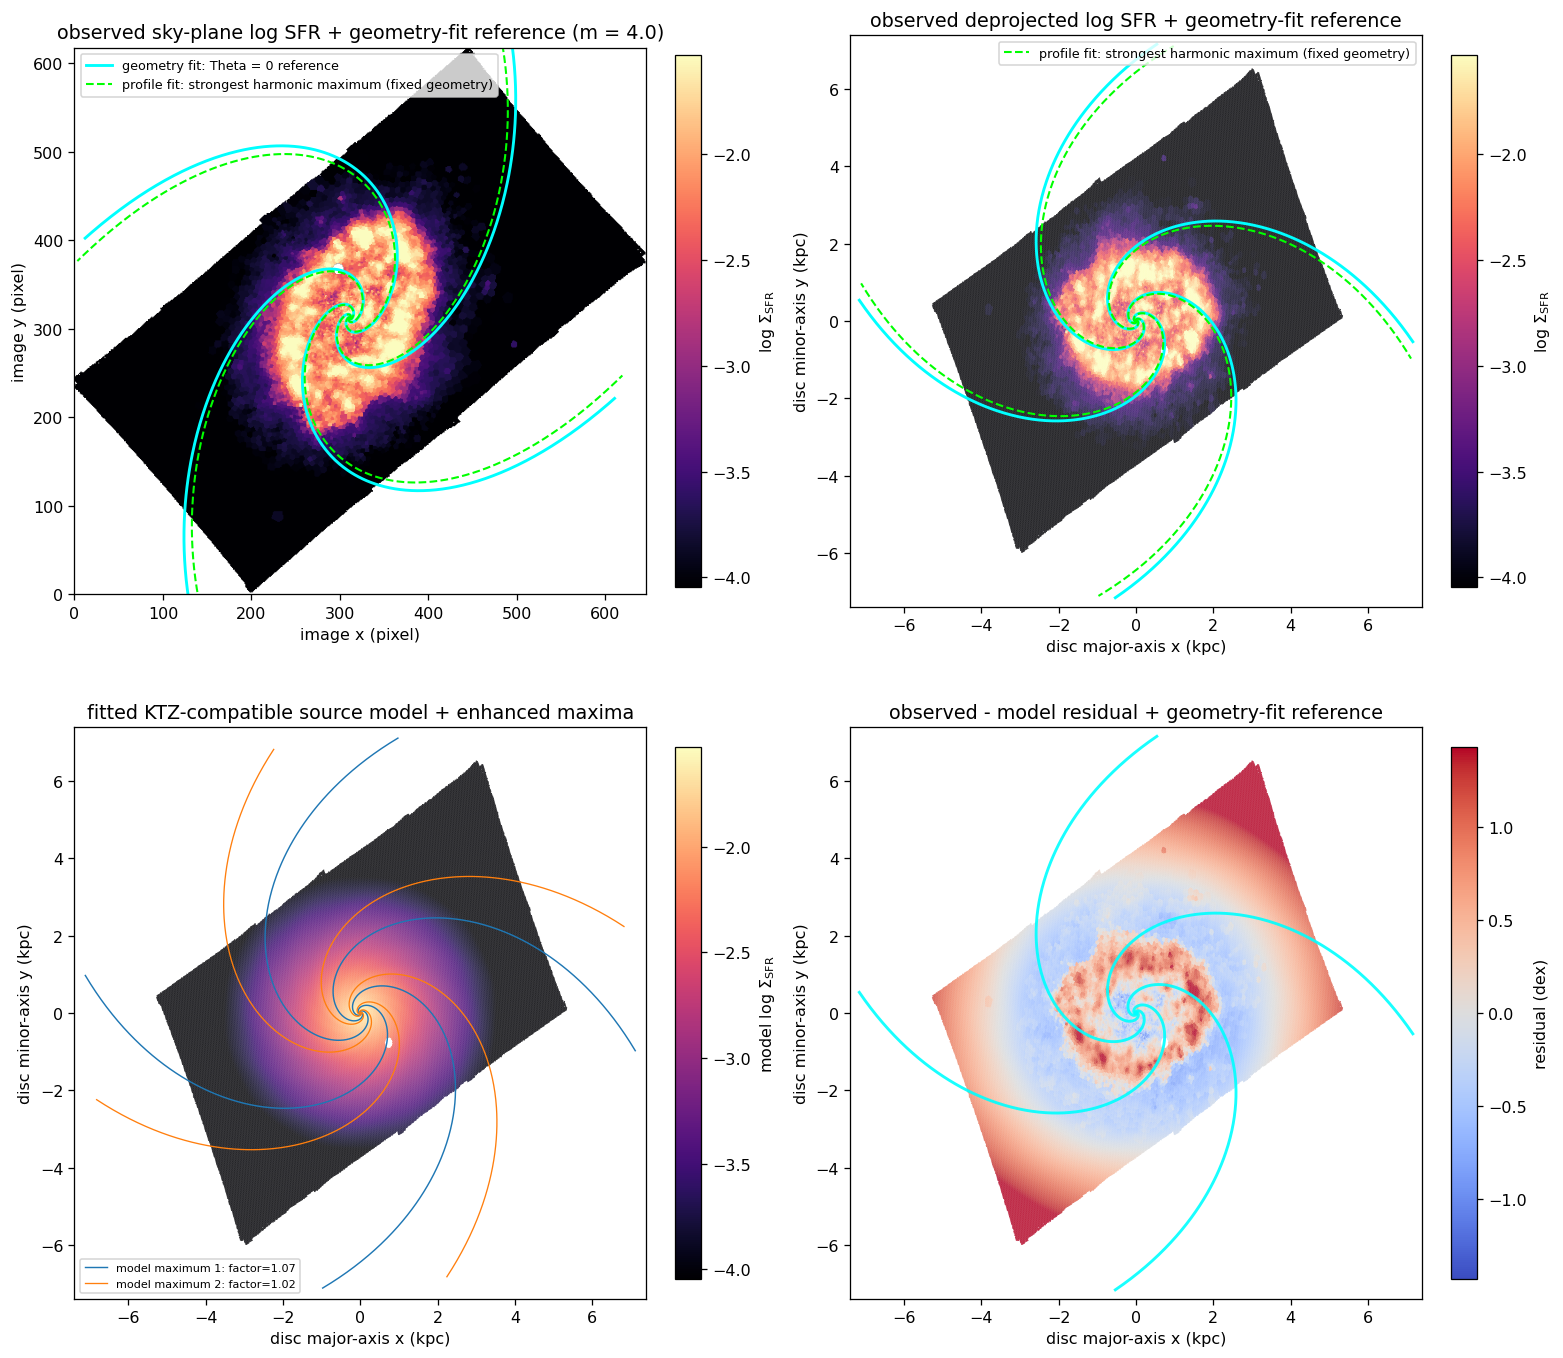

DEPROJECTED_SFR_SKELETON_PASS


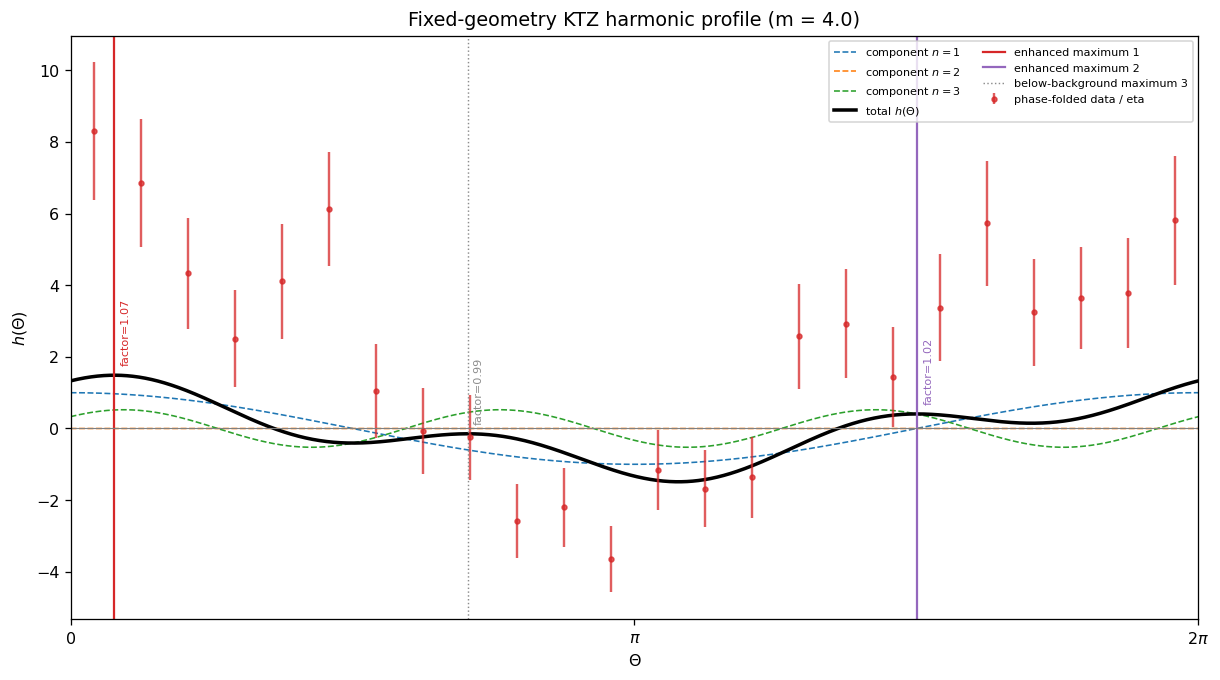

Minimum fitted rate factor: 0.9321
POSITIVITY_CHECK_PASS


,parameter,estimate,unit_or_convention,status
0,R_in,0.004136,kpc,all positive-radius valid HII bins; no hole
1,R_out,6.384442,kpc,all valid HII bins; no quantile cut
2,ridge_R_in,0.004136,kpc,all positive-radius valid HII pixels
3,ridge_R_out,7.176088,kpc,all valid HII morphology pixels
4,m_arms,4,integer base mode,geometry fit; frozen during profile fit
5,pitch_angle,-38.558602,signed deg,geometry fit; frozen during profile fit
6,Theta0,3.307055,rad modulo 2 pi,geometry fit; frozen during profile fit
7,ridge_core_width,0.25,kpc,declared fiducial local-ridge scale
8,lambda0_0,0.030414,SFR surface-density normalization,fixed-geometry KTZ fit; uncertainty not estimated
9,h_R,0.615768,kpc,axisymmetric SFR e-folding length; fixed-geome...


,theta_peak,h_peak,rate_factor,enhanced_above_background
0,0.244506,1.488077,1.067884,True
1,4.714613,0.406623,1.018550,True
2,2.212171,-0.147397,0.993276,False


FINAL_PARAMETER_TABLE_COMPLETE


In [15]:
# Retrieve best-fit geometry for m=4 and run evaluation and plotting
geometry_fit_m4 = geometry_fit_table.loc[geometry_fit_table["m_arms"] == 4].iloc[0].to_dict()
profile_fit_m4 = evaluate_geometry_and_profile_for_m(geometry_fit_m4)

## Geometry and Fixed-Geometry Profile Results for m = 5

/opt/miniconda3/envs/ICRAR/lib/python3.13/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/opt/miniconda3/envs/ICRAR/lib/python3.13/site-packages/scipy/optimize/_slsqp_py.py:439: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
/opt/miniconda3/envs/ICRAR/lib/python3.13/site-packages/scipy/optimize/_slsqp_py.py:499: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_ieq = vstack([con['jac'](x, *con['args'])


Geometry/profile consistency: m, signed pitch, and Theta0 are frozen; strongest harmonic maximum has wrapped delta Theta=0.480 rad


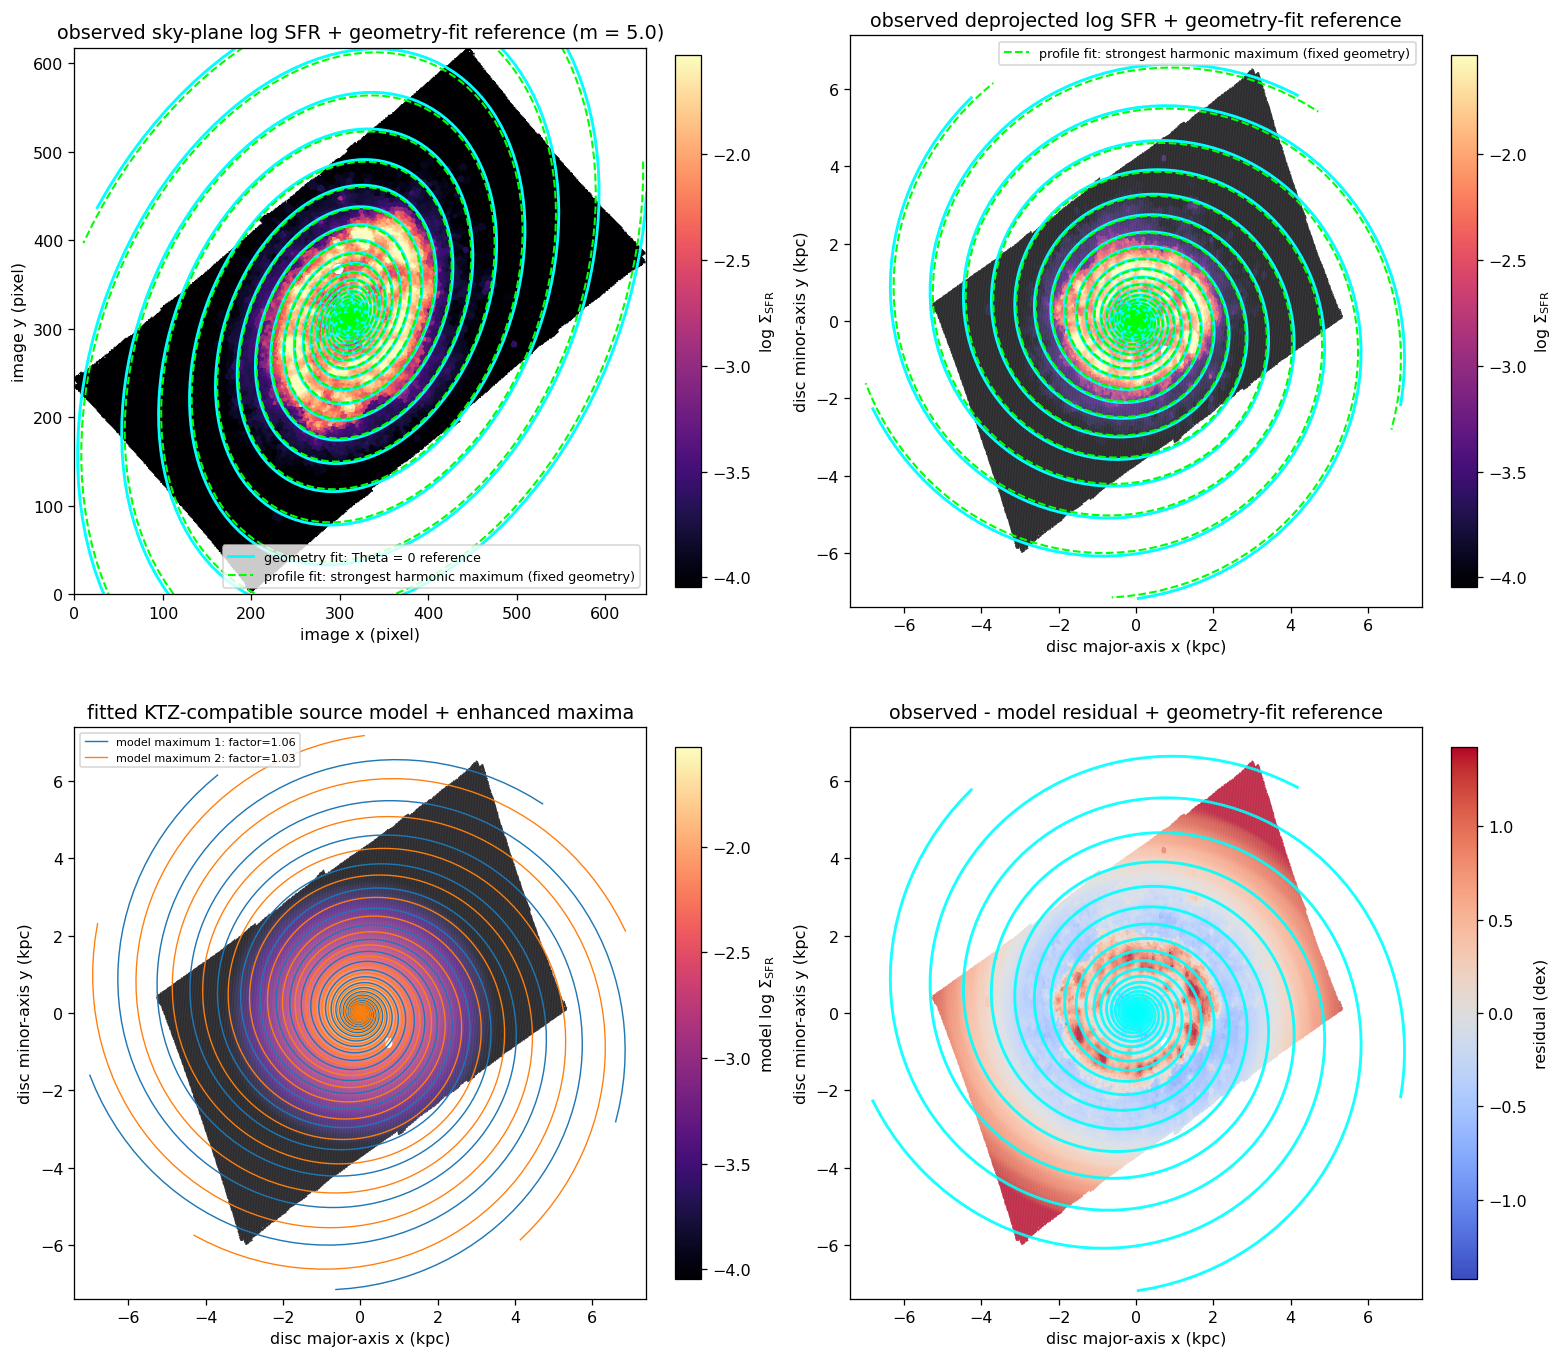

DEPROJECTED_SFR_SKELETON_PASS


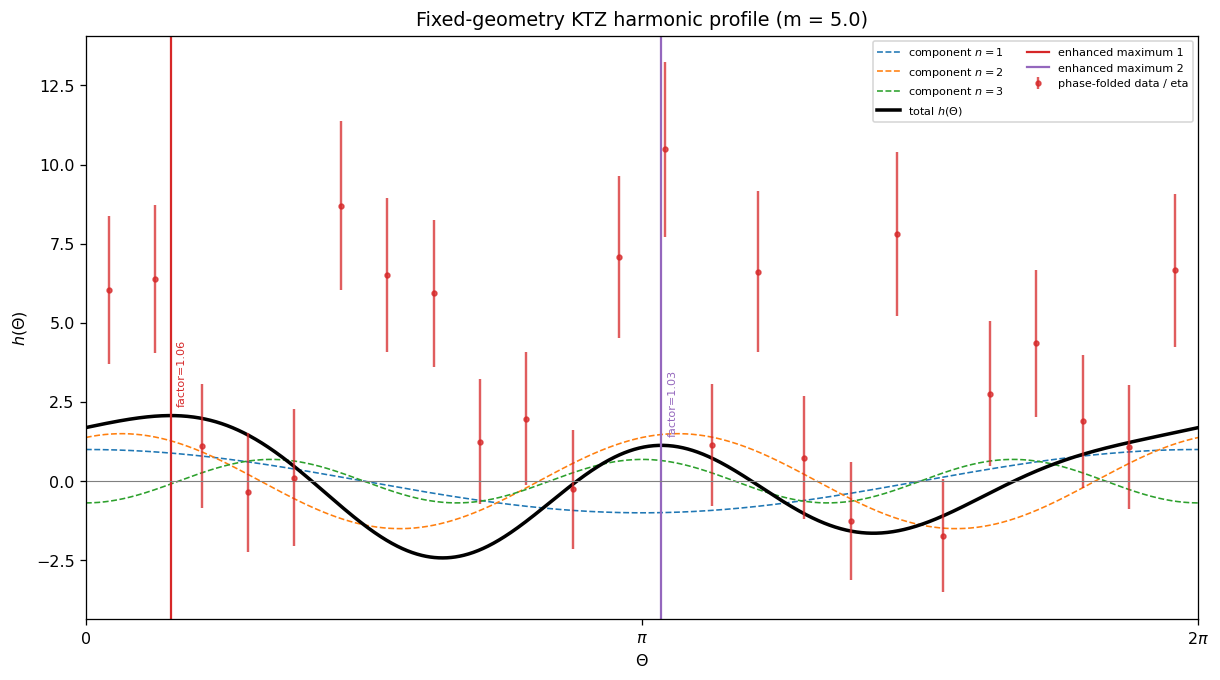

Minimum fitted rate factor: 0.9297
POSITIVITY_CHECK_PASS


,parameter,estimate,unit_or_convention,status
0,R_in,0.004136,kpc,all positive-radius valid HII bins; no hole
1,R_out,6.384442,kpc,all valid HII bins; no quantile cut
2,ridge_R_in,0.004136,kpc,all positive-radius valid HII pixels
3,ridge_R_out,7.176088,kpc,all valid HII morphology pixels
4,m_arms,5,integer base mode,geometry fit; frozen during profile fit
5,pitch_angle,-7.995725,signed deg,geometry fit; frozen during profile fit
6,Theta0,5.787886,rad modulo 2 pi,geometry fit; frozen during profile fit
7,ridge_core_width,0.25,kpc,declared fiducial local-ridge scale
8,lambda0_0,0.030457,SFR surface-density normalization,fixed-geometry KTZ fit; uncertainty not estimated
9,h_R,0.614866,kpc,axisymmetric SFR e-folding length; fixed-geome...


,theta_peak,h_peak,rate_factor,enhanced_above_background
0,0.479560,2.071282,1.060047,True
1,3.250679,1.130728,1.032780,True


FINAL_PARAMETER_TABLE_COMPLETE


In [16]:
# Retrieve best-fit geometry for m=5 and run evaluation and plotting
geometry_fit_m5 = geometry_fit_table.loc[geometry_fit_table["m_arms"] == 5].iloc[0].to_dict()
profile_fit_m5 = evaluate_geometry_and_profile_for_m(geometry_fit_m5)

## Geometry and Fixed-Geometry Profile Results for m = 6

/opt/miniconda3/envs/ICRAR/lib/python3.13/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


Geometry/profile consistency: m, signed pitch, and Theta0 are frozen; strongest harmonic maximum has wrapped delta Theta=0.985 rad


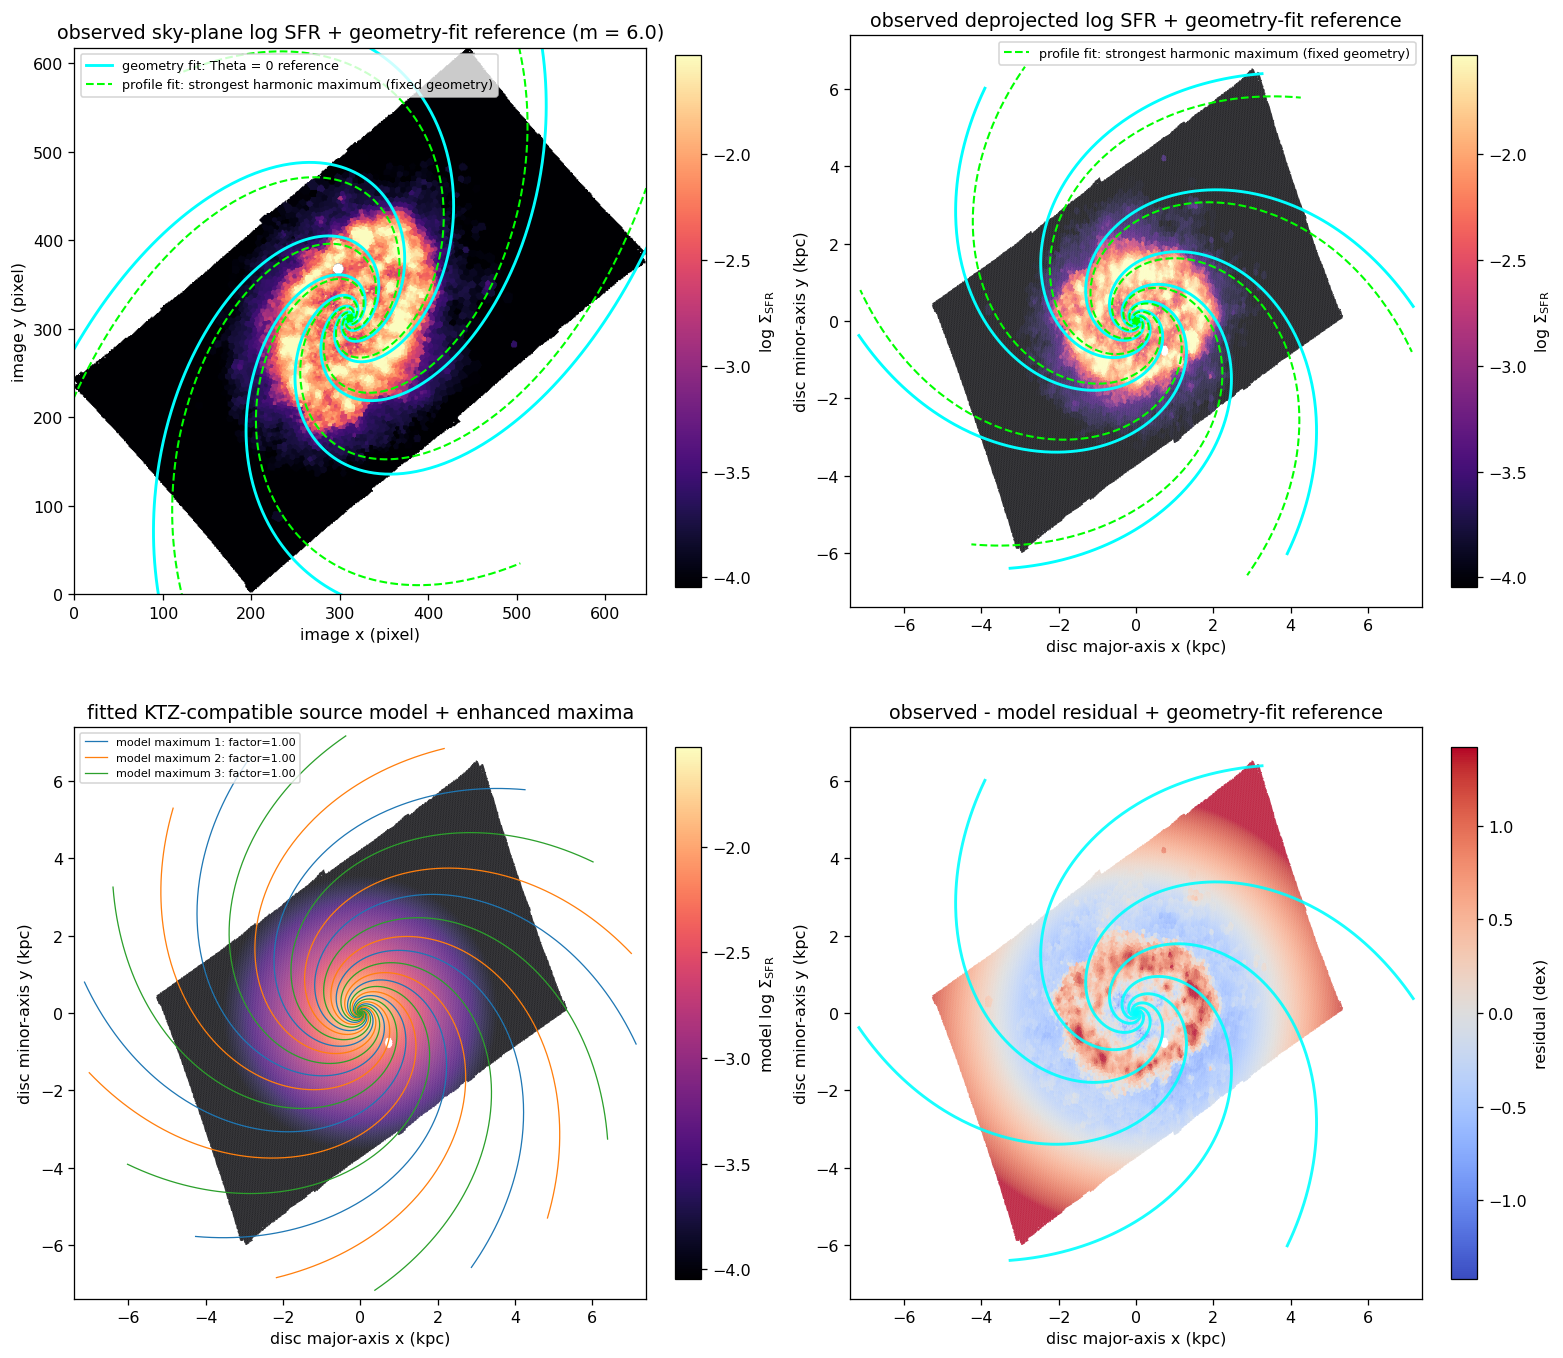

DEPROJECTED_SFR_SKELETON_PASS


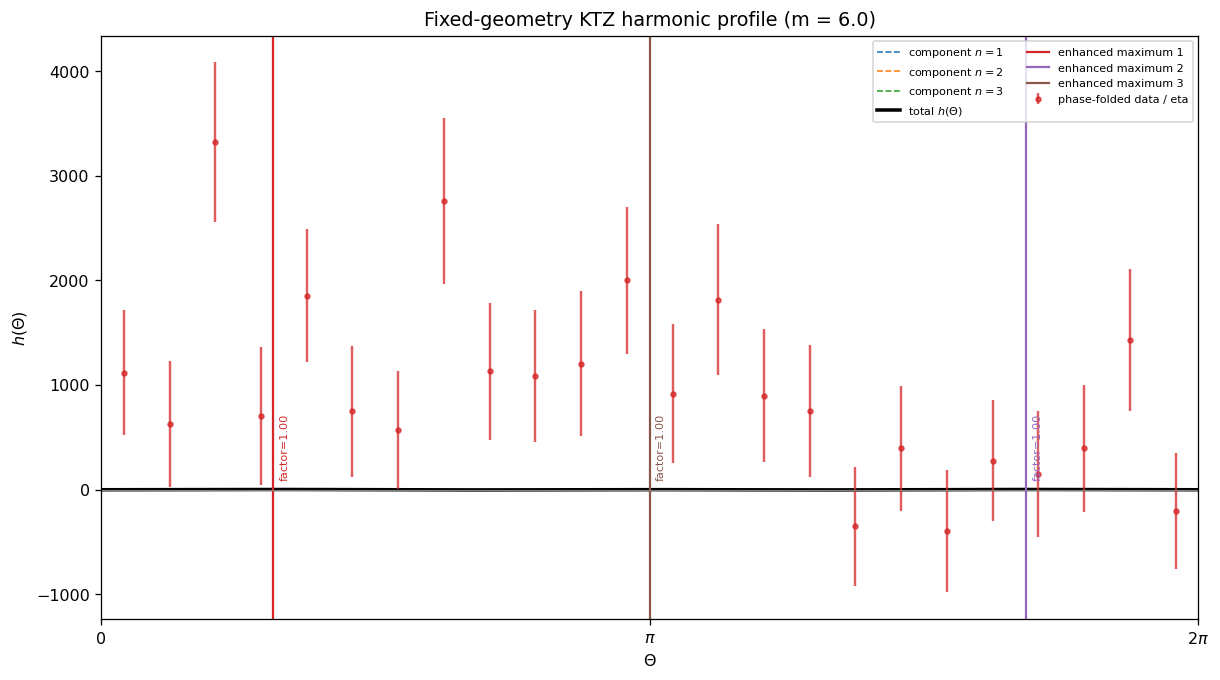

Minimum fitted rate factor: 0.9998
POSITIVITY_CHECK_PASS


,parameter,estimate,unit_or_convention,status
0,R_in,0.004136,kpc,all positive-radius valid HII bins; no hole
1,R_out,6.384442,kpc,all valid HII bins; no quantile cut
2,ridge_R_in,0.004136,kpc,all positive-radius valid HII pixels
3,ridge_R_out,7.176088,kpc,all valid HII morphology pixels
4,m_arms,6,integer base mode,geometry fit; frozen during profile fit
5,pitch_angle,-31.343018,signed deg,geometry fit; frozen during profile fit
6,Theta0,0.880328,rad modulo 2 pi,geometry fit; frozen during profile fit
7,ridge_core_width,0.25,kpc,declared fiducial local-ridge scale
8,lambda0_0,0.03049,SFR surface-density normalization,fixed-geometry KTZ fit; uncertainty not estimated
9,h_R,0.614721,kpc,axisymmetric SFR e-folding length; fixed-geome...


,theta_peak,h_peak,rate_factor,enhanced_above_background
0,0.985111,2.026826,1.000203,True
1,5.298075,2.026826,1.000203,True
2,3.141593,0.500000,1.000050,True


FINAL_PARAMETER_TABLE_COMPLETE


In [17]:
# Retrieve best-fit geometry for m=6 and run evaluation and plotting
geometry_fit_m6 = geometry_fit_table.loc[geometry_fit_table["m_arms"] == 6].iloc[0].to_dict()
profile_fit_m6 = evaluate_geometry_and_profile_for_m(geometry_fit_m6)